# History-based difficulty predictor
Build recurring-prompt history table,
Create no-leakage history features,
Predict next pass rate / dead flag,
Compare vs text-only baseline,
# Better response-length predictor
Add reasoning/content features,
Handle 1024-token censoring,
Fit content + history model,
Evaluate held-out correlation,
# Scheduler ablation
Oracle,
Predicted,
Random / NoOp,
Simulate makespan + skip quality,
Plot benefit vs prediction error,
# Predictor contract
Define scheduler-facing output,
Benchmark 128-prompt prediction cost,
Mark trustworthy vs weak fields,
Define cold-start = do not skip,

# 1. History-based difficulty predictor

In [2]:
from pathlib import Path

DATA_DIR = Path(
    r"C:\Users\waqar\OneDrive\Desktop\Fellowship\epoch_rollout_data"
)

assert DATA_DIR.exists(), f"Folder not found: {DATA_DIR}"

def sort_key(path):
    try:
        return int(path.stem)
    except ValueError:
        return path.stem

jsonl_files = sorted(
    DATA_DIR.glob("*.jsonl"),
    key=sort_key
)

print("DATA_DIR:", DATA_DIR)
print("\nFiles found:")

for f in jsonl_files:
    print(" ", f.name)

print("\nTotal JSONL files:", len(jsonl_files))

assert len(jsonl_files) == 6, (
    f"Expected 6 JSONL files for Week 5, found {len(jsonl_files)}"
)

DATA_DIR: C:\Users\waqar\OneDrive\Desktop\Fellowship\epoch_rollout_data

Files found:
  1.jsonl
  2.jsonl
  3.jsonl
  4.jsonl
  5.jsonl
  6.jsonl

Total JSONL files: 6


# Loading and concatenating all six files

In [3]:
import json
import pandas as pd

frames = []

for f in jsonl_files:
    batch_step = int(f.stem)

    with f.open("r", encoding="utf-8") as fh:
        rows = [json.loads(line) for line in fh if line.strip()]

    df_part = pd.DataFrame(rows)

    # Preserves where every row came from
    df_part["batch_step"] = batch_step
    df_part["source_file"] = f.name

    frames.append(df_part)

raw_df = pd.concat(frames, ignore_index=True)

# Keep rows in chronological file order
raw_df = (
    raw_df
    .sort_values(["batch_step"])
    .reset_index(drop=True)
)

print("Combined shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

print("\nRows per batch:")
print(raw_df.groupby("batch_step").size())

print("\nFirst 5 rows:")
display(raw_df.head())

Combined shape: (7680, 8)

Columns:
['input', 'output', 'gts', 'score', 'step', 'uid', 'batch_step', 'source_file']

Rows per batch:
batch_step
1    1280
2    1280
3    1280
4    1280
5    1280
6    1280
dtype: int64

First 5 rows:


,input,output,gts,score,step,uid,batch_step,source_file
0,"system\nPlease reason step by step, and put yo...","Please reason step by step, and put your final...",448000,0.0,1,08722274-b6b2-42c5-b1e9-d093e89927ba_4_0,1,1.jsonl
1,"system\nPlease reason step by step, and put yo...",The ratio of coins that Elsa has to that which...,90,1.0,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_0_0,1,1.jsonl
2,"system\nPlease reason step by step, and put yo...","To solve the problem, let's follow these steps...",90,1.0,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_1_0,1,1.jsonl
3,"system\nPlease reason step by step, and put yo...","To solve the problem, we will follow these ste...",90,1.0,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_2_0,1,1.jsonl
4,"system\nPlease reason step by step, and put yo...","To solve this problem, we can break it down in...",90,1.0,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_3_0,1,1.jsonl


# Audit UID format + padding rows

In [4]:
print("=== UID / PADDING AUDIT ===")

print("\nSample UIDs from each batch:")
for batch in sorted(raw_df["batch_step"].unique()):
    sample_uids = (
        raw_df.loc[raw_df["batch_step"] == batch, "uid"]
        .astype(str)
        .head(10)
        .tolist()
    )

    print(f"\nBatch {batch}:")
    for uid in sample_uids:
        print(" ", uid)

# Padding indicators described in the Week 5 cookbook
uid_is_pad = raw_df["uid"].astype(str).str.startswith("pad", na=False)

input_blank = (
    raw_df["input"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

output_blank = (
    raw_df["output"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

print("\n=== Padding diagnostics ===")
print("Rows with uid starting 'pad':", uid_is_pad.sum())
print("Rows with blank input:", input_blank.sum())
print("Rows with blank output:", output_blank.sum())

print("\nRows satisfying all 3 padding signals:")
print((uid_is_pad & input_blank & output_blank).sum())

print("\nExample suspected padding rows:")
display(
    raw_df.loc[
        uid_is_pad | (input_blank & output_blank),
        ["batch_step", "uid", "input", "output"]
    ].head(20)
)

=== UID / PADDING AUDIT ===

Sample UIDs from each batch:

Batch 1:
  08722274-b6b2-42c5-b1e9-d093e89927ba_4_0
  0a4d41f5-dd74-4851-8354-77ccd41d65a7_0_0
  0a4d41f5-dd74-4851-8354-77ccd41d65a7_1_0
  0a4d41f5-dd74-4851-8354-77ccd41d65a7_2_0
  0a4d41f5-dd74-4851-8354-77ccd41d65a7_3_0
  0a4d41f5-dd74-4851-8354-77ccd41d65a7_4_0
  0c38b85c-6a68-45c6-82ce-5078edd4bf9c_0_0
  0c38b85c-6a68-45c6-82ce-5078edd4bf9c_1_0
  06cf923b-4776-41f4-a489-cbfae9bb9e40_1_0
  06cf923b-4776-41f4-a489-cbfae9bb9e40_2_0

Batch 2:
  01dda951-d153-432c-a4c9-27133d15d9ff_0_0
  01dda951-d153-432c-a4c9-27133d15d9ff_1_0
  01dda951-d153-432c-a4c9-27133d15d9ff_2_0
  01dda951-d153-432c-a4c9-27133d15d9ff_3_0
  01dda951-d153-432c-a4c9-27133d15d9ff_4_0
  02a27fd4-70b0-4610-870c-9de6881d33f4_0_0
  02a27fd4-70b0-4610-870c-9de6881d33f4_1_0
  02a27fd4-70b0-4610-870c-9de6881d33f4_2_0
  02a27fd4-70b0-4610-870c-9de6881d33f4_3_0
  02a27fd4-70b0-4610-870c-9de6881d33f4_4_0

Batch 3:
  10692c3d-6844-4a8e-8017-48b4c73a88dc_2_0
  10692c3

,batch_step,uid,input,output
576,1,pad1e13d174580049f29c8381782243f07c_24_0,,
577,1,pad1e13d174580049f29c8381782243f07c_25_0,,
578,1,pad1e13d174580049f29c8381782243f07c_26_0,,
579,1,pad1e13d174580049f29c8381782243f07c_27_0,,
580,1,pad1e13d174580049f29c8381782243f07c_28_0,,
581,1,pad1e13d174580049f29c8381782243f07c_29_0,,
582,1,pad1e13d174580049f29c8381782243f07c_30_0,,
583,1,pad1e13d174580049f29c8381782243f07c_31_0,,
584,1,pad1e13d174580049f29c8381782243f07c_16_0,,
585,1,pad1e13d174580049f29c8381782243f07c_17_0,,


# Removing padding + recovering prompt_id

In [5]:
# ------------------------------------------------------------
# Step 3: clean padding rows and recover stable prompt_id
# ------------------------------------------------------------

uid_str = raw_df["uid"].fillna("").astype(str)

uid_is_pad = uid_str.str.startswith("pad")

input_blank = (
    raw_df["input"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

output_blank = (
    raw_df["output"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

# First prove the three padding indicators agree exactly.
print("Padding mask agreement:")
print("uid pad == blank input :", (uid_is_pad == input_blank).all())
print("uid pad == blank output:", (uid_is_pad == output_blank).all())
print(
    "all three agree        :",
    ((uid_is_pad == input_blank) & (uid_is_pad == output_blank)).all()
)

assert (uid_is_pad == input_blank).all()
assert (uid_is_pad == output_blank).all()

# Remove padding.
clean_df = (
    raw_df.loc[~uid_is_pad]
    .copy()
    .reset_index(drop=True)
)

# UID format:
# <prompt_id>_<rollout_index>_<suffix>
#
# Strip ONLY the final two numeric components.
clean_df["prompt_id"] = (
    clean_df["uid"]
    .astype(str)
    .str.replace(r"_\d+_\d+$", "", regex=True)
)

# Extract rollout index as an audit field.
clean_df["rollout_idx"] = (
    clean_df["uid"]
    .astype(str)
    .str.extract(r"_(\d+)_\d+$")[0]
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("\nRaw rows:", len(raw_df))
print("Padding removed:", uid_is_pad.sum())
print("Real rows remaining:", len(clean_df))

print("\nReal rows per batch:")
print(clean_df.groupby("batch_step").size())

print("\nUnique prompt IDs per batch:")
print(clean_df.groupby("batch_step")["prompt_id"].nunique())

print("\nRollouts per (batch, prompt) distribution:")
rollout_counts = (
    clean_df
    .groupby(["batch_step", "prompt_id"])
    .size()
)

print(rollout_counts.value_counts().sort_index())

print("\nMissing recovered prompt IDs:", clean_df["prompt_id"].isna().sum())
print("Missing rollout indices:", clean_df["rollout_idx"].isna().sum())

print("\nExample recovered IDs:")
display(
    clean_df[
        ["batch_step", "uid", "prompt_id", "rollout_idx"]
    ].head(12)
)

Padding mask agreement:
uid pad == blank input : True
uid pad == blank output: True
all three agree        : True

Raw rows: 7680
Padding removed: 3840
Real rows remaining: 3840

Real rows per batch:
batch_step
1    640
2    640
3    640
4    640
5    640
6    640
dtype: int64

Unique prompt IDs per batch:
batch_step
1    128
2    128
3    128
4    128
5    128
6    128
Name: prompt_id, dtype: int64

Rollouts per (batch, prompt) distribution:
5    768
Name: count, dtype: int64

Missing recovered prompt IDs: 0
Missing rollout indices: 0

Example recovered IDs:


,batch_step,uid,prompt_id,rollout_idx
0,1,08722274-b6b2-42c5-b1e9-d093e89927ba_4_0,08722274-b6b2-42c5-b1e9-d093e89927ba,4
1,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_0_0,0a4d41f5-dd74-4851-8354-77ccd41d65a7,0
2,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_1_0,0a4d41f5-dd74-4851-8354-77ccd41d65a7,1
3,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_2_0,0a4d41f5-dd74-4851-8354-77ccd41d65a7,2
4,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_3_0,0a4d41f5-dd74-4851-8354-77ccd41d65a7,3
5,1,0a4d41f5-dd74-4851-8354-77ccd41d65a7_4_0,0a4d41f5-dd74-4851-8354-77ccd41d65a7,4
6,1,0c38b85c-6a68-45c6-82ce-5078edd4bf9c_0_0,0c38b85c-6a68-45c6-82ce-5078edd4bf9c,0
7,1,0c38b85c-6a68-45c6-82ce-5078edd4bf9c_1_0,0c38b85c-6a68-45c6-82ce-5078edd4bf9c,1
8,1,06cf923b-4776-41f4-a489-cbfae9bb9e40_1_0,06cf923b-4776-41f4-a489-cbfae9bb9e40,1
9,1,06cf923b-4776-41f4-a489-cbfae9bb9e40_2_0,06cf923b-4776-41f4-a489-cbfae9bb9e40,2


# Verify rollout groups + recurrence structure

The Week 5 cookbook specifies UID-derived prompt identity. In the supplied export, UUIDs are regenerated across revisits. Exact input strings nevertheless reproduce the intended 1→4, 2→5, 3→6 recurrence structure perfectly, with 384 prompts appearing exactly twice and consistent ground truth. We therefore use a deterministic hash of the exact input string as the stable prompt identifier for this analysis.

In [6]:
import hashlib

def make_stable_prompt_id(text):
    return hashlib.sha256(
        str(text).encode("utf-8")
    ).hexdigest()

# Stable identity across revisits
clean_df["prompt_id"] = (
    clean_df["input"]
    .astype(str)
    .map(make_stable_prompt_id)
)

# ------------------------------------------------------------
# Verify recurrence
# ------------------------------------------------------------

prompt_recurrence = (
    clean_df[["prompt_id", "batch_step"]]
    .drop_duplicates()
    .groupby("prompt_id")["batch_step"]
    .apply(lambda x: tuple(sorted(x)))
)

print("Unique stable prompts:", clean_df["prompt_id"].nunique())

print("\nRecurrence patterns:")
print(prompt_recurrence.value_counts().sort_index())

print("\nAppearances per prompt:")
print(
    prompt_recurrence
    .apply(len)
    .value_counts()
    .sort_index()
)

# Check that one hash never maps to multiple prompt strings
hash_check = (
    clean_df[["prompt_id", "input"]]
    .drop_duplicates()
    .groupby("prompt_id")["input"]
    .nunique()
)

print("\nHash collisions:", (hash_check > 1).sum())

assert clean_df["prompt_id"].nunique() == 384
assert set(prompt_recurrence.unique()) == {
    (1, 4),
    (2, 5),
    (3, 6),
}
assert prompt_recurrence.apply(len).eq(2).all()
assert (hash_check > 1).sum() == 0

print("\n✓ Stable recurring prompt IDs recovered successfully.")

Unique stable prompts: 384

Recurrence patterns:
batch_step
(1, 4)    128
(2, 5)    128
(3, 6)    128
Name: count, dtype: int64

Appearances per prompt:
batch_step
2    384
Name: count, dtype: int64

Hash collisions: 0

✓ Stable recurring prompt IDs recovered successfully.


# prompt-occurrence outcome table

In [8]:
# ------------------------------------------------------------
# Step 5: build one row per prompt occurrence
# ------------------------------------------------------------
import numpy as np
# First verify the reward/score field before using it.
print("Unique score values:")
print(sorted(clean_df["score"].dropna().unique()))

print("\nMissing scores:", clean_df["score"].isna().sum())

# DUET expects binary rollout rewards for this analysis.
assert clean_df["score"].notna().all(), "Found missing score values."
assert set(clean_df["score"].unique()).issubset({0.0, 1.0}), (
    "Expected binary scores {0, 1}."
)

# Aggregate the 5 rollouts belonging to each prompt occurrence.
prompt_occ = (
    clean_df
    .groupby(["batch_step", "prompt_id"], as_index=False)
    .agg(
        input=("input", "first"),
        gts=("gts", "first"),
        pass_rate=("score", "mean"),
        reward_var=("score", lambda x: x.var(ddof=0)),
        n_rollouts=("score", "size"),
    )
)

# A prompt occurrence is "dead" if every rollout passed
# OR every rollout failed.
prompt_occ["dead"] = (
    prompt_occ["pass_rate"].isin([0.0, 1.0])
).astype(int)

# Helpful semantic label for inspection only.
prompt_occ["status"] = np.select(
    [
        prompt_occ["pass_rate"].eq(0.0),
        prompt_occ["pass_rate"].eq(1.0),
    ],
    [
        "all_fail",
        "all_pass",
    ],
    default="productive",
)

# Sort chronologically.
prompt_occ = (
    prompt_occ
    .sort_values(["batch_step", "prompt_id"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

print("\nPrompt-occurrence table shape:", prompt_occ.shape)

print("\nPrompt occurrences per batch:")
print(prompt_occ.groupby("batch_step").size())

print("\nRollouts per occurrence:")
print(prompt_occ["n_rollouts"].value_counts().sort_index())

print("\nPass-rate distribution:")
print(prompt_occ["pass_rate"].value_counts().sort_index())

print("\nDead flag distribution:")
print(prompt_occ["dead"].value_counts().sort_index())

print("\nStatus distribution:")
print(prompt_occ["status"].value_counts())

assert len(prompt_occ) == 768
assert prompt_occ["n_rollouts"].eq(5).all()

print("\n✓ Prompt-occurrence outcome table built successfully.")

display(
    prompt_occ[
        [
            "batch_step",
            "prompt_id",
            "pass_rate",
            "dead",
            "status",
            "n_rollouts",
        ]
    ].head(10)
)

Unique score values:
[np.float64(0.0), np.float64(1.0)]

Missing scores: 0

Prompt-occurrence table shape: (768, 9)

Prompt occurrences per batch:
batch_step
1    128
2    128
3    128
4    128
5    128
6    128
dtype: int64

Rollouts per occurrence:
n_rollouts
5    768
Name: count, dtype: int64

Pass-rate distribution:
pass_rate
0.0    306
0.2    239
0.4    126
0.6     62
0.8     28
1.0      7
Name: count, dtype: int64

Dead flag distribution:
dead
0    455
1    313
Name: count, dtype: int64

Status distribution:
status
productive    455
all_fail      306
all_pass        7
Name: count, dtype: int64

✓ Prompt-occurrence outcome table built successfully.


,batch_step,prompt_id,pass_rate,dead,status,n_rollouts
0,1,02713d7b3b0bf524cefa0fe529a29220859c96b726c5b8...,0.0,1,all_fail,5
1,1,0855552350d222c39b04a10dc2cd817df27e8b988888df...,0.0,1,all_fail,5
2,1,0a26db3dfffc482ccd6b7584b0e0d3fac571576236f429...,0.6,0,productive,5
3,1,0c15d20fc0ac0ee24e8c4ec7b57654a0d5e6a6c005c249...,0.0,1,all_fail,5
4,1,0c2b3406905425fdd2357880133da25a3a13e92427c422...,0.4,0,productive,5
5,1,0d2d37b0c46b6dea2e8d10e80391adad14183f26c4869a...,0.4,0,productive,5
6,1,0d38025978d7233ce18dc28e6ae97901969ed0295f7b79...,0.2,0,productive,5
7,1,0d86b7a6d1bf580b973ef5c67939c79ac3f7b26e263647...,0.0,1,all_fail,5
8,1,0def1b1a5ef60cd33739e2bb2f107bf2a070c6e7a9f5ff...,0.0,1,all_fail,5
9,1,10a30ead3bdc5920206a2634110dc974fbb87990aacb03...,0.0,1,all_fail,5


# Compute response-token lengths

In [9]:
# ------------------------------------------------------------
# Step 6: tokenize rollout responses and add length statistics
# ------------------------------------------------------------

from transformers import AutoTokenizer
import numpy as np

TOKENIZER_NAME = "Qwen/Qwen2.5-Math-1.5B"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

outputs = clean_df["output"].fillna("").astype(str).tolist()

# Tokenize in batches to avoid holding all tokenized outputs
# in memory at once.
BATCH_SIZE = 128
resp_lengths = []

for start in range(0, len(outputs), BATCH_SIZE):
    batch_text = outputs[start:start + BATCH_SIZE]

    encoded = tokenizer(
        batch_text,
        add_special_tokens=False,
        truncation=False,
    )

    resp_lengths.extend(
        [len(ids) for ids in encoded["input_ids"]]
    )

clean_df["resp_len"] = resp_lengths

# Basic rollout-level checks
print("=== ROLLOUT RESPONSE LENGTHS ===")
print(clean_df["resp_len"].describe())

print("\nZero-length responses:", clean_df["resp_len"].eq(0).sum())
print("Missing response lengths:", clean_df["resp_len"].isna().sum())

# Aggregate length outcomes per prompt occurrence
length_occ = (
    clean_df
    .groupby(["batch_step", "prompt_id"], as_index=False)
    .agg(
        mean_resp_len=("resp_len", "mean"),
        resp_len_var=("resp_len", lambda x: x.var(ddof=0)),
        min_resp_len=("resp_len", "min"),
        max_resp_len=("resp_len", "max"),
    )
)

# Attach to the prompt-occurrence table
prompt_occ = prompt_occ.merge(
    length_occ,
    on=["batch_step", "prompt_id"],
    how="left",
    validate="one_to_one",
)

print("\n=== PROMPT-OCCURRENCE LENGTH STATS ===")
print("Shape:", prompt_occ.shape)

print("\nMean response length:")
print(prompt_occ["mean_resp_len"].describe())

print("\nResponse-length variance:")
print(prompt_occ["resp_len_var"].describe())

print("\nMissing mean lengths:", prompt_occ["mean_resp_len"].isna().sum())
print("Missing variances:", prompt_occ["resp_len_var"].isna().sum())

assert len(prompt_occ) == 768
assert prompt_occ["mean_resp_len"].notna().all()
assert prompt_occ["resp_len_var"].notna().all()

print("\n✓ Response-length statistics added successfully.")

c:\Users\waqar\OneDrive\Desktop\Fellowship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== ROLLOUT RESPONSE LENGTHS ===
count    3840.000000
mean      547.897135
std       352.520088
min         1.000000
25%       254.000000
50%       452.000000
75%      1022.000000
max      1130.000000
Name: resp_len, dtype: float64

Zero-length responses: 0
Missing response lengths: 0

=== PROMPT-OCCURRENCE LENGTH STATS ===
Shape: (768, 13)

Mean response length:
count     768.000000
mean      547.897135
std       162.616940
min       133.800000
25%       427.900000
50%       542.400000
75%       656.350000
max      1025.000000
Name: mean_resp_len, dtype: float64

Response-length variance:
count       768.000000
mean      97828.214063
std       49327.637495
min           7.200000
25%       62744.160000
50%      102726.800000
75%      130092.940000
max      246797.440000
Name: resp_len_var, dtype: float64

Missing mean lengths: 0
Missing variances: 0

✓ Response-length statistics added successfully.


# chronological history table

In [10]:
# ------------------------------------------------------------
# Step 7: strict no-leakage history feature construction
# ------------------------------------------------------------

# Always sort by stable prompt identity + chronology BEFORE shifting.
history_df = (
    prompt_occ
    .sort_values(["prompt_id", "batch_step"])
    .copy()
    .reset_index(drop=True)
)

g = history_df.groupby("prompt_id", sort=False)

# Number of appearances BEFORE the current occurrence.
history_df["n_prev"] = g.cumcount()

# Previous occurrence metadata/outcomes.
history_df["prev_batch_step"] = g["batch_step"].shift(1)
history_df["prev_pass_rate"] = g["pass_rate"].shift(1)
history_df["prev_dead"] = g["dead"].shift(1)
history_df["prev_mean_resp_len"] = g["mean_resp_len"].shift(1)
history_df["prev_resp_len_var"] = g["resp_len_var"].shift(1)

# ------------------------------------------------------------
# Dead-streak feature
#
# Defined as the number of CONSECUTIVE dead occurrences immediately
# preceding the current one.
#
# This implementation works even if Sam later gives us 3+ revisits.
# ------------------------------------------------------------

def prior_dead_streak(dead_values):
    streaks = []
    streak = 0

    for dead in dead_values:
        # Record history BEFORE observing current occurrence.
        streaks.append(streak)

        if dead == 1:
            streak += 1
        else:
            streak = 0

    return pd.Series(streaks, index=dead_values.index)

history_df["prev_dead_streak"] = (
    history_df
    .groupby("prompt_id", group_keys=False)["dead"]
    .apply(prior_dead_streak)
)

# Current occurrence is the TARGET.
history_df["target_pass_rate"] = history_df["pass_rate"]
history_df["target_dead"] = history_df["dead"]

# ------------------------------------------------------------
# Audit cold-start vs history-available rows
# ------------------------------------------------------------

print("=== HISTORY AVAILABILITY ===")

print("\nn_prev distribution:")
print(history_df["n_prev"].value_counts().sort_index())

print(
    "\nCold-start rows:",
    history_df["n_prev"].eq(0).sum()
)

print(
    "Rows with usable history:",
    history_df["n_prev"].gt(0).sum()
)

print(
    "Cold-start fraction:",
    f"{history_df['n_prev'].eq(0).mean():.3f}"
)

# Only revisits can be used for the Week 5 next-occurrence task.
revisit_df = (
    history_df.loc[history_df["n_prev"] > 0]
    .copy()
    .reset_index(drop=True)
)

print("\n=== REVISIT TABLE ===")
print("Shape:", revisit_df.shape)

print("\nEarlier → later batch pairs:")
print(
    revisit_df[
        ["prev_batch_step", "batch_step"]
    ]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Strict no-leakage assertions
# ------------------------------------------------------------

assert len(history_df) == 768
assert len(revisit_df) == 384

# Every revisit must have an earlier batch.
assert (
    revisit_df["prev_batch_step"]
    < revisit_df["batch_step"]
).all()

# All history features must exist for revisit rows.
HISTORY_FEATURES = [
    "prev_pass_rate",
    "prev_dead",
    "prev_dead_streak",
    "prev_mean_resp_len",
    "prev_resp_len_var",
]

assert revisit_df[HISTORY_FEATURES].notna().all().all()

# The supplied POC should preserve exactly these chronological pairs.
observed_pairs = set(
    map(
        tuple,
        revisit_df[
            ["prev_batch_step", "batch_step"]
        ]
        .drop_duplicates()
        .astype(int)
        .to_numpy()
    )
)

assert observed_pairs == {
    (1, 4),
    (2, 5),
    (3, 6),
}

print("\n✓ History features use only earlier occurrences.")
print("✓ 384 valid earlier → later prediction examples.")
print("✓ No same-occurrence outcome was used as a history feature.")

display(
    revisit_df[
        [
            "prompt_id",
            "prev_batch_step",
            "batch_step",
            "n_prev",
            "prev_pass_rate",
            "prev_dead",
            "prev_dead_streak",
            "prev_mean_resp_len",
            "prev_resp_len_var",
            "target_pass_rate",
            "target_dead",
        ]
    ].head(10)
)

=== HISTORY AVAILABILITY ===

n_prev distribution:
n_prev
0    384
1    384
Name: count, dtype: int64

Cold-start rows: 384
Rows with usable history: 384
Cold-start fraction: 0.500

=== REVISIT TABLE ===
Shape: (384, 22)

Earlier → later batch pairs:
prev_batch_step  batch_step
1.0              4             128
2.0              5             128
3.0              6             128
Name: count, dtype: int64

✓ History features use only earlier occurrences.
✓ 384 valid earlier → later prediction examples.
✓ No same-occurrence outcome was used as a history feature.


,prompt_id,prev_batch_step,batch_step,n_prev,prev_pass_rate,prev_dead,prev_dead_streak,prev_mean_resp_len,prev_resp_len_var,target_pass_rate,target_dead
0,014901f5ff40fa0c87438bbf13db75b3c4a0f72c7422f1...,3.0,6,1,0.0,1.0,1,770.2,121368.16,0.0,1
1,01c477f21d5b5b53165d2be0db0d4a25f35a453e889039...,2.0,5,1,0.4,0.0,0,503.8,185100.96,0.4,0
2,02713d7b3b0bf524cefa0fe529a29220859c96b726c5b8...,1.0,4,1,0.0,1.0,1,623.8,216612.96,0.6,0
3,03fccf4dad4ea71c2f8a5e47233784867c402f0f036f8a...,2.0,5,1,0.0,1.0,1,796.0,107450.80,0.2,0
4,057129532eb358ba34cabfe98dd2c19c28d58f7e378768...,2.0,5,1,0.0,1.0,1,600.4,147219.44,0.0,1
5,066c32164111b1f9a8bccd3b53830d9cfad1f7ba488b99...,2.0,5,1,0.0,1.0,1,444.6,224429.44,0.2,0
6,07b1b432534b30906213cb65f54e56c93f855f2f6512b6...,3.0,6,1,0.0,1.0,1,540.0,116384.80,0.4,0
7,0855552350d222c39b04a10dc2cd817df27e8b988888df...,1.0,4,1,0.0,1.0,1,627.2,140643.36,0.0,1
8,089e91d78d1ab1b85404328a7440bc3101932618c4f658...,2.0,5,1,0.4,0.0,0,659.0,91280.80,0.0,1
9,09e08ce6d9100ca0836656de45b0e83a495001a0c5d9a7...,2.0,5,1,0.4,0.0,0,538.6,169345.84,0.4,0


# Single-feature history baseline

In [11]:
# ------------------------------------------------------------
# Step 8: history baseline before fitting any model
# ------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# ------------------------------------------------------------
# Continuous target:
# previous pass rate -> next-occurrence pass rate
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    revisit_df["prev_pass_rate"],
    revisit_df["target_pass_rate"],
)

spearman_r, spearman_p = spearmanr(
    revisit_df["prev_pass_rate"],
    revisit_df["target_pass_rate"],
)

print("=== NEXT PASS-RATE BASELINE ===")
print(f"Pearson r  : {pearson_r:.4f}")
print(f"Pearson p  : {pearson_p:.3e}")
print(f"Spearman r : {spearman_r:.4f}")
print(f"Spearman p : {spearman_p:.3e}")

print("\nText-only Week 5 comparison baseline: r = 0.12")
print(f"Improvement over r=0.12: {pearson_r - 0.12:+.4f}")

# ------------------------------------------------------------
# Binary target:
# previous dead flag -> next dead flag
# ------------------------------------------------------------

y_true = revisit_df["target_dead"].astype(int)
y_pred = revisit_df["prev_dead"].astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# prev_dead is binary, but it can still be used as a simple score for AUC
auc = roc_auc_score(y_true, revisit_df["prev_dead"])

cm = confusion_matrix(y_true, y_pred)

print("\n=== NEXT DEAD-FLAG BASELINE ===")
print(f"Precision (dead): {precision:.4f}")
print(f"Recall (dead)   : {recall:.4f}")
print(f"F1 (dead)       : {f1:.4f}")
print(f"ROC AUC         : {auc:.4f}")

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nTarget dead prevalence:")
print(y_true.value_counts(normalize=True).sort_index())

=== NEXT PASS-RATE BASELINE ===
Pearson r  : 0.4791
Pearson p  : 1.989e-23
Spearman r : 0.4196
Spearman p : 8.252e-18

Text-only Week 5 comparison baseline: r = 0.12
Improvement over r=0.12: +0.3591

=== NEXT DEAD-FLAG BASELINE ===
Precision (dead): 0.5000
Recall (dead)   : 0.5944
F1 (dead)       : 0.5431
ROC AUC         : 0.6209

Confusion matrix [[TN, FP], [FN, TP]]:
[[156  85]
 [ 58  85]]

Target dead prevalence:
target_dead
0    0.627604
1    0.372396
Name: proportion, dtype: float64


# Create chronological train / validation / test sets

In [12]:
# ------------------------------------------------------------
# Step 9: chronological train / validation / test split
# ------------------------------------------------------------

train_df = (
    revisit_df.loc[
        (revisit_df["prev_batch_step"] == 1) &
        (revisit_df["batch_step"] == 4)
    ]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    revisit_df.loc[
        (revisit_df["prev_batch_step"] == 2) &
        (revisit_df["batch_step"] == 5)
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    revisit_df.loc[
        (revisit_df["prev_batch_step"] == 3) &
        (revisit_df["batch_step"] == 6)
    ]
    .copy()
    .reset_index(drop=True)
)

print("=== CHRONOLOGICAL SPLIT ===")
print("Train: 1 → 4 :", len(train_df))
print("Val:   2 → 5 :", len(val_df))
print("Test:  3 → 6 :", len(test_df))

print("\n=== TARGET PASS RATE ===")
for name, df in [
    ("Train", train_df),
    ("Val", val_df),
    ("Test", test_df),
]:
    print(
        f"{name:5s} | "
        f"mean={df['target_pass_rate'].mean():.4f} | "
        f"std={df['target_pass_rate'].std():.4f}"
    )

print("\n=== TARGET DEAD PREVALENCE ===")
for name, df in [
    ("Train", train_df),
    ("Val", val_df),
    ("Test", test_df),
]:
    print(
        f"{name:5s} | "
        f"dead={df['target_dead'].mean():.4f} | "
        f"productive={1 - df['target_dead'].mean():.4f}"
    )

# Stable prompts must not overlap across these cohorts.
train_ids = set(train_df["prompt_id"])
val_ids = set(val_df["prompt_id"])
test_ids = set(test_df["prompt_id"])

print("\nPrompt overlap:")
print("Train ∩ Val :", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test  :", len(val_ids & test_ids))

assert len(train_df) == 128
assert len(val_df) == 128
assert len(test_df) == 128

assert not (train_ids & val_ids)
assert not (train_ids & test_ids)
assert not (val_ids & test_ids)

assert train_df["batch_step"].max() < val_df["batch_step"].min()
assert val_df["batch_step"].max() < test_df["batch_step"].min()

print("\n✓ Chronological held-out split created.")
print("✓ Final test set is batch 3 → 6 and remains untouched.")

=== CHRONOLOGICAL SPLIT ===
Train: 1 → 4 : 128
Val:   2 → 5 : 128
Test:  3 → 6 : 128

=== TARGET PASS RATE ===
Train | mean=0.2250 | std=0.2407
Val   | mean=0.2344 | std=0.2422
Test  | mean=0.2094 | std=0.2021

=== TARGET DEAD PREVALENCE ===
Train | dead=0.3906 | productive=0.6094
Val   | dead=0.3516 | productive=0.6484
Test  | dead=0.3750 | productive=0.6250

Prompt overlap:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

✓ Chronological held-out split created.
✓ Final test set is batch 3 → 6 and remains untouched.


# Held-out baseline on validation only

In [13]:
# ------------------------------------------------------------
# Step 10: held-out history baseline
# TRAIN + VALIDATION ONLY
# Do not touch test_df metrics yet.
# ------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

def evaluate_simple_history_baseline(df, name):
    # Continuous:
    # previous pass rate -> next pass rate
    pearson_r, pearson_p = pearsonr(
        df["prev_pass_rate"],
        df["target_pass_rate"],
    )

    spearman_r, spearman_p = spearmanr(
        df["prev_pass_rate"],
        df["target_pass_rate"],
    )

    # Binary:
    # previous dead -> next dead
    y_true = df["target_dead"].astype(int)
    y_pred = df["prev_dead"].astype(int)

    precision = precision_score(
        y_true, y_pred, zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )
    auc = roc_auc_score(
        y_true,
        df["prev_dead"].astype(float),
    )

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n=== {name} ===")

    print("\nNext pass rate:")
    print(f"Pearson r   : {pearson_r:.4f}")
    print(f"Pearson p   : {pearson_p:.3e}")
    print(f"Spearman r  : {spearman_r:.4f}")
    print(f"Spearman p  : {spearman_p:.3e}")

    print("\nNext dead flag:")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"F1          : {f1:.4f}")
    print(f"ROC AUC     : {auc:.4f}")

    print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
    print(cm)

    return {
        "split": name,
        "pearson_r": pearson_r,
        "spearman_r": spearman_r,
        "dead_precision": precision,
        "dead_recall": recall,
        "dead_f1": f1,
        "dead_auc": auc,
    }


train_baseline = evaluate_simple_history_baseline(
    train_df,
    "TRAIN 1→4"
)

val_baseline = evaluate_simple_history_baseline(
    val_df,
    "VALIDATION 2→5"
)

print("\n=== WEEK 5 CHECKPOINT ===")
print("Text-only reference r = 0.12")
print(
    "Validation previous-pass-rate improvement:",
    f"{val_baseline['pearson_r'] - 0.12:+.4f}"
)

if val_baseline["pearson_r"] > 0.12:
    print("✓ Previous pass rate beats the text-only reference on validation.")
else:
    print("✗ Previous pass rate does NOT beat the text-only reference.")


=== TRAIN 1→4 ===

Next pass rate:
Pearson r   : 0.4640
Pearson p   : 3.451e-08
Spearman r  : 0.3702
Spearman p  : 1.703e-05

Next dead flag:
Precision   : 0.4464
Recall      : 0.5000
F1          : 0.4717
ROC AUC     : 0.5513

Confusion matrix [[TN, FP], [FN, TP]]:
[[47 31]
 [25 25]]

=== VALIDATION 2→5 ===

Next pass rate:
Pearson r   : 0.5486
Pearson p   : 2.036e-11
Spearman r  : 0.4898
Spearman p  : 4.417e-09

Next dead flag:
Precision   : 0.5185
Recall      : 0.6222
F1          : 0.5657
ROC AUC     : 0.6545

Confusion matrix [[TN, FP], [FN, TP]]:
[[57 26]
 [17 28]]

=== WEEK 5 CHECKPOINT ===
Text-only reference r = 0.12
Validation previous-pass-rate improvement: +0.4286
✓ Previous pass rate beats the text-only reference on validation.


# Fit the first multi-feature history models

In [14]:
# ------------------------------------------------------------
# Step 11: fit multi-feature history models
# TRAIN on 1→4
# EVALUATE on 2→5 only
# TEST 3→6 stays untouched
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from scipy.stats import pearsonr, spearmanr
import numpy as np

# prev_dead_streak is intentionally omitted here because with
# exactly one prior occurrence it is identical to prev_dead.
HISTORY_MODEL_FEATURES = [
    "prev_pass_rate",
    "prev_dead",
    "prev_mean_resp_len",
    "prev_resp_len_var",
]

X_train = train_df[HISTORY_MODEL_FEATURES]
X_val = val_df[HISTORY_MODEL_FEATURES]

y_train_pass = train_df["target_pass_rate"]
y_val_pass = val_df["target_pass_rate"]

y_train_dead = train_df["target_dead"].astype(int)
y_val_dead = val_df["target_dead"].astype(int)

# ------------------------------------------------------------
# Continuous head: next pass rate
# ------------------------------------------------------------

pass_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

pass_model.fit(X_train, y_train_pass)

val_pass_pred = pass_model.predict(X_val)

# Pass rate is naturally bounded [0, 1].
# Keep raw predictions for model diagnostics, and clipped predictions
# for scheduler-facing interpretation.
val_pass_pred_clipped = np.clip(val_pass_pred, 0.0, 1.0)

pearson_r = pearsonr(
    val_pass_pred,
    y_val_pass
).statistic

spearman_r = spearmanr(
    val_pass_pred,
    y_val_pass
).statistic

mae = mean_absolute_error(
    y_val_pass,
    val_pass_pred_clipped
)

rmse = np.sqrt(
    mean_squared_error(
        y_val_pass,
        val_pass_pred_clipped
    )
)

print("=== MULTI-FEATURE PASS-RATE MODEL — VALIDATION 2→5 ===")
print(f"Pearson r : {pearson_r:.4f}")
print(f"Spearman r: {spearman_r:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

print("\nSingle-feature validation baseline:")
print(f"Pearson r : {val_baseline['pearson_r']:.4f}")

print(
    "Δ Pearson :",
    f"{pearson_r - val_baseline['pearson_r']:+.4f}"
)

# ------------------------------------------------------------
# Binary head: next dead flag
# ------------------------------------------------------------

dead_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
        )
    ),
])

dead_model.fit(X_train, y_train_dead)

val_dead_prob = dead_model.predict_proba(X_val)[:, 1]

# Default threshold only for first inspection.
val_dead_pred = (val_dead_prob >= 0.5).astype(int)

auc = roc_auc_score(
    y_val_dead,
    val_dead_prob
)

precision = precision_score(
    y_val_dead,
    val_dead_pred,
    zero_division=0
)

recall = recall_score(
    y_val_dead,
    val_dead_pred,
    zero_division=0
)

f1 = f1_score(
    y_val_dead,
    val_dead_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_val_dead,
    val_dead_pred
)

print("\n=== MULTI-FEATURE DEAD MODEL — VALIDATION 2→5 ===")
print(f"ROC AUC          : {auc:.4f}")
print(f"Precision @ 0.50 : {precision:.4f}")
print(f"Recall @ 0.50    : {recall:.4f}")
print(f"F1 @ 0.50        : {f1:.4f}")

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nSingle-feature dead baseline:")
print(f"AUC       : {val_baseline['dead_auc']:.4f}")
print(f"Precision : {val_baseline['dead_precision']:.4f}")
print(f"Recall    : {val_baseline['dead_recall']:.4f}")

print("\n✓ Models trained on 1→4 and evaluated only on 2→5.")
print("✓ Final 3→6 test set remains untouched.")

=== MULTI-FEATURE PASS-RATE MODEL — VALIDATION 2→5 ===
Pearson r : 0.5418
Spearman r: 0.4475
MAE       : 0.1547
RMSE      : 0.2041

Single-feature validation baseline:
Pearson r : 0.5486
Δ Pearson : -0.0068

=== MULTI-FEATURE DEAD MODEL — VALIDATION 2→5 ===
ROC AUC          : 0.6506
Precision @ 0.50 : 0.4000
Recall @ 0.50    : 0.5778
F1 @ 0.50        : 0.4727

Confusion matrix [[TN, FP], [FN, TP]]:
[[44 39]
 [19 26]]

Single-feature dead baseline:
AUC       : 0.6545
Precision : 0.5185
Recall    : 0.6222

✓ Models trained on 1→4 and evaluated only on 2→5.
✓ Final 3→6 test set remains untouched.


# Inspect the actual transition table

In [15]:
# ------------------------------------------------------------
# Step 12: inspect next-occurrence behavior by previous pass rate
# TRAIN and VALIDATION only
# ------------------------------------------------------------

def transition_table(df, name):
    table = (
        df
        .groupby("prev_pass_rate")
        .agg(
            n=("target_dead", "size"),
            next_mean_pass_rate=("target_pass_rate", "mean"),
            next_dead_rate=("target_dead", "mean"),
        )
        .reset_index()
        .sort_values("prev_pass_rate")
    )

    print(f"\n=== {name} ===")
    display(table)

    return table


train_transition = transition_table(
    train_df,
    "TRAIN 1→4"
)

val_transition = transition_table(
    val_df,
    "VALIDATION 2→5"
)

print("\n=== COUNTS OF PREVIOUS PASS-RATE LEVELS ===")

print("\nTrain:")
print(
    train_df["prev_pass_rate"]
    .value_counts()
    .sort_index()
)

print("\nValidation:")
print(
    val_df["prev_pass_rate"]
    .value_counts()
    .sort_index()
)


=== TRAIN 1→4 ===


,prev_pass_rate,n,next_mean_pass_rate,next_dead_rate
0,0.0,53,0.143396,0.471698
1,0.2,37,0.178378,0.459459
2,0.4,24,0.350000,0.208333
3,0.6,9,0.333333,0.333333
4,0.8,2,0.600000,0.000000
5,1.0,3,0.666667,0.000000



=== VALIDATION 2→5 ===


,prev_pass_rate,n,next_mean_pass_rate,next_dead_rate
0,0.0,54,0.122222,0.518519
1,0.2,36,0.238889,0.250000
2,0.4,18,0.233333,0.333333
3,0.6,13,0.492308,0.000000
4,0.8,7,0.600000,0.285714



=== COUNTS OF PREVIOUS PASS-RATE LEVELS ===

Train:
prev_pass_rate
0.0    53
0.2    37
0.4    24
0.6     9
0.8     2
1.0     3
Name: count, dtype: int64

Validation:
prev_pass_rate
0.0    54
0.2    36
0.4    18
0.6    13
0.8     7
Name: count, dtype: int64


# Compare simple dead-ranking signals

In [16]:
# ------------------------------------------------------------
# Step 13: compare simple history signals for NEXT dead status
# VALIDATION ONLY
# ------------------------------------------------------------

from sklearn.metrics import roc_auc_score

y_val_dead = val_df["target_dead"].astype(int)

# Candidate 1:
# old binary rule: previously dead -> more likely dead next time
score_prev_dead = val_df["prev_dead"].astype(float)

# Candidate 2:
# lower previous pass rate -> more likely to be dead next time
score_low_pass = 1.0 - val_df["prev_pass_rate"]

auc_prev_dead = roc_auc_score(
    y_val_dead,
    score_prev_dead
)

auc_low_pass = roc_auc_score(
    y_val_dead,
    score_low_pass
)

print("=== DEAD-RANKING SIGNALS — VALIDATION 2→5 ===")
print(f"Previous dead flag AUC : {auc_prev_dead:.4f}")
print(f"1 - previous pass AUC  : {auc_low_pass:.4f}")
print(
    f"Δ AUC                  : "
    f"{auc_low_pass - auc_prev_dead:+.4f}"
)

# ------------------------------------------------------------
# Also inspect precision/recall for simple pass-rate cutoffs.
# These are diagnostics only; we are NOT selecting the final
# threshold yet.
# ------------------------------------------------------------

from sklearn.metrics import precision_score, recall_score

print("\n=== SIMPLE LOW-PASS CUT-OFFS ===")

for cutoff in [0.0, 0.2, 0.4, 0.6]:
    pred_dead = (
        val_df["prev_pass_rate"] <= cutoff
    ).astype(int)

    precision = precision_score(
        y_val_dead,
        pred_dead,
        zero_division=0
    )

    recall = recall_score(
        y_val_dead,
        pred_dead,
        zero_division=0
    )

    n_predicted_dead = pred_dead.sum()

    print(
        f"prev_pass_rate <= {cutoff:.1f} | "
        f"predicted dead={n_predicted_dead:3d} | "
        f"precision={precision:.4f} | "
        f"recall={recall:.4f}"
    )

print("\n✓ Final test 3→6 remains untouched.")

=== DEAD-RANKING SIGNALS — VALIDATION 2→5 ===
Previous dead flag AUC : 0.6545
1 - previous pass AUC  : 0.6695
Δ AUC                  : +0.0150

=== SIMPLE LOW-PASS CUT-OFFS ===
prev_pass_rate <= 0.0 | predicted dead= 54 | precision=0.5185 | recall=0.6222
prev_pass_rate <= 0.2 | predicted dead= 90 | precision=0.4111 | recall=0.8222
prev_pass_rate <= 0.4 | predicted dead=108 | precision=0.3981 | recall=0.9556
prev_pass_rate <= 0.6 | predicted dead=121 | precision=0.3554 | recall=0.9556

✓ Final test 3→6 remains untouched.


# Fit the simple one-feature dead-probability model

In [17]:
# ------------------------------------------------------------
# Step 14: simple one-feature dead probability model
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
)

X_train_1 = train_df[["prev_pass_rate"]]
X_val_1 = val_df[["prev_pass_rate"]]

y_train_dead = train_df["target_dead"].astype(int)
y_val_dead = val_df["target_dead"].astype(int)

# Unweighted logistic regression:
# we care about probability quality, not merely class balance.
dead_model_1f = LogisticRegression(
    max_iter=2000,
    random_state=42,
)

dead_model_1f.fit(X_train_1, y_train_dead)

val_dead_prob_1f = dead_model_1f.predict_proba(X_val_1)[:, 1]

auc_1f = roc_auc_score(
    y_val_dead,
    val_dead_prob_1f
)

ap_1f = average_precision_score(
    y_val_dead,
    val_dead_prob_1f
)

brier_1f = brier_score_loss(
    y_val_dead,
    val_dead_prob_1f
)

print("=== 1-FEATURE DEAD-PROBABILITY MODEL — VALIDATION 2→5 ===")
print(f"ROC AUC           : {auc_1f:.4f}")
print(f"Average precision : {ap_1f:.4f}")
print(f"Brier score       : {brier_1f:.4f}")

print("\nModel parameters:")
print(
    "Intercept:",
    round(float(dead_model_1f.intercept_[0]), 4)
)
print(
    "prev_pass_rate coefficient:",
    round(float(dead_model_1f.coef_[0][0]), 4)
)

# Show the probability assigned to each possible previous pass rate.
possible_rates = np.array(
    [[0.0], [0.2], [0.4], [0.6], [0.8], [1.0]]
)

prob_by_rate = dead_model_1f.predict_proba(
    possible_rates
)[:, 1]

print("\nPredicted next-dead probability:")
for rate, prob in zip(possible_rates.ravel(), prob_by_rate):
    print(
        f"prev_pass_rate={rate:.1f} "
        f"→ predicted_dead_prob={prob:.4f}"
    )

# Default 0.50 threshold, for diagnostics only.
pred_050 = (val_dead_prob_1f >= 0.50).astype(int)

print("\n@ threshold 0.50:")
print(
    "Precision:",
    f"{precision_score(y_val_dead, pred_050, zero_division=0):.4f}"
)
print(
    "Recall   :",
    f"{recall_score(y_val_dead, pred_050, zero_division=0):.4f}"
)
print(
    "F1       :",
    f"{f1_score(y_val_dead, pred_050, zero_division=0):.4f}"
)

print("\n✓ Test 3→6 still untouched.")

=== 1-FEATURE DEAD-PROBABILITY MODEL — VALIDATION 2→5 ===
ROC AUC           : 0.6695
Average precision : 0.4736
Brier score       : 0.2158

Model parameters:
Intercept: -0.184
prev_pass_rate coefficient: -1.2936

Predicted next-dead probability:
prev_pass_rate=0.0 → predicted_dead_prob=0.4541
prev_pass_rate=0.2 → predicted_dead_prob=0.3911
prev_pass_rate=0.4 → predicted_dead_prob=0.3315
prev_pass_rate=0.6 → predicted_dead_prob=0.2768
prev_pass_rate=0.8 → predicted_dead_prob=0.2281
prev_pass_rate=1.0 → predicted_dead_prob=0.1858

@ threshold 0.50:
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000

✓ Test 3→6 still untouched.


c:\Users\waqar\OneDrive\Desktop\Fellowship\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Validation threshold sweep

In [18]:
# ------------------------------------------------------------
# Step 15: choose a SAFE dead-probability threshold
# VALIDATION ONLY
# ------------------------------------------------------------

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Because prev_pass_rate is discrete, the model also produces
# only a small number of distinct probabilities.
candidate_thresholds = sorted(
    np.unique(val_dead_prob_1f),
    reverse=True
)

rows = []

for threshold in candidate_thresholds:
    pred = (val_dead_prob_1f >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_dead,
        pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_val_dead,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_dead,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_dead,
        pred,
        zero_division=0
    )

    # Among truly informative prompts, how many would we wrongly skip?
    informative_skip_rate = (
        fp / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    rows.append({
        "threshold": threshold,
        "n_skipped": int(pred.sum()),
        "skip_fraction": pred.mean(),
        "precision_dead": precision,
        "recall_dead": recall,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "informative_skip_rate": informative_skip_rate,
    })

threshold_table = pd.DataFrame(rows)

print("=== VALIDATION THRESHOLD TRADE-OFF ===")
display(
    threshold_table.round(4)
)

print("\nReminder:")
print("Higher precision = fewer wasted/unsafe skips.")
print("Higher recall    = more dead prompts successfully removed.")
print("Informative skip rate = fraction of useful prompts wrongly skipped.")

print("\n✓ Final test 3→6 remains untouched.")

=== VALIDATION THRESHOLD TRADE-OFF ===


,threshold,n_skipped,skip_fraction,precision_dead,recall_dead,f1,TP,FP,FN,TN,informative_skip_rate
0,0.4541,54,0.4219,0.5185,0.6222,0.5657,28,26,17,57,0.3133
1,0.3911,90,0.7031,0.4111,0.8222,0.5481,37,53,8,30,0.6386
2,0.3315,108,0.8438,0.3981,0.9556,0.5621,43,65,2,18,0.7831
3,0.2768,121,0.9453,0.3554,0.9556,0.5181,43,78,2,5,0.9398
4,0.2281,128,1.0000,0.3516,1.0000,0.5202,45,83,0,0,1.0000



Reminder:
Higher precision = fewer wasted/unsafe skips.
Higher recall    = more dead prompts successfully removed.
Informative skip rate = fraction of useful prompts wrongly skipped.

✓ Final test 3→6 remains untouched.


# Final held-out test, opened once

In [19]:
# ------------------------------------------------------------
# Step 16: FINAL held-out evaluation on 3→6
# Model choices were fixed using train/validation only.
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np

# ============================================================
# Freeze design choices BEFORE reading test performance
# ============================================================

# Continuous head:
# Best validation model = previous pass rate directly.
#
# Binary head:
# Best ranking signal = previous pass rate only.
#
# Validation-selected skip rule:
# only treat prompts with previous pass_rate == 0.0 as dead enough
# to skip.
SKIP_PREV_PASS_CUTOFF = 0.0

# ============================================================
# Refit dead-probability model on all PRE-TEST examples
# ============================================================

dev_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

X_dev = dev_df[["prev_pass_rate"]]
y_dev_dead = dev_df["target_dead"].astype(int)

final_dead_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
)

final_dead_model.fit(
    X_dev,
    y_dev_dead
)

# ============================================================
# FINAL TEST: 3 → 6
# ============================================================

# ------------------------------------------------------------
# Continuous target
# prediction = previous pass rate
# ------------------------------------------------------------

test_pass_pred = test_df["prev_pass_rate"].to_numpy()
y_test_pass = test_df["target_pass_rate"].to_numpy()

test_pearson = pearsonr(
    test_pass_pred,
    y_test_pass
)

test_spearman = spearmanr(
    test_pass_pred,
    y_test_pass
)

print("=== FINAL TEST: NEXT PASS RATE — 3→6 ===")
print(f"Pearson r  : {test_pearson.statistic:.4f}")
print(f"Pearson p  : {test_pearson.pvalue:.3e}")
print(f"Spearman r : {test_spearman.statistic:.4f}")
print(f"Spearman p : {test_spearman.pvalue:.3e}")

print("\nText-only reference: r = 0.12")
print(
    "Improvement:",
    f"{test_pearson.statistic - 0.12:+.4f}"
)

# ------------------------------------------------------------
# Binary target
# ------------------------------------------------------------

X_test = test_df[["prev_pass_rate"]]
y_test_dead = test_df["target_dead"].astype(int)

test_dead_prob = final_dead_model.predict_proba(
    X_test
)[:, 1]

test_auc = roc_auc_score(
    y_test_dead,
    test_dead_prob
)

test_ap = average_precision_score(
    y_test_dead,
    test_dead_prob
)

test_brier = brier_score_loss(
    y_test_dead,
    test_dead_prob
)

# Validation-selected semantic skip rule:
# previous pass rate == 0.0
test_skip_pred = (
    test_df["prev_pass_rate"]
    <= SKIP_PREV_PASS_CUTOFF
).astype(int)

test_precision = precision_score(
    y_test_dead,
    test_skip_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_dead,
    test_skip_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_dead,
    test_skip_pred,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_test_dead,
    test_skip_pred,
    labels=[0, 1]
).ravel()

informative_skip_rate = fp / (tn + fp)

print("\n=== FINAL TEST: NEXT DEAD FLAG — 3→6 ===")
print(f"ROC AUC           : {test_auc:.4f}")
print(f"Average precision : {test_ap:.4f}")
print(f"Brier score       : {test_brier:.4f}")

print(
    "\nValidation-selected skip rule:",
    "prev_pass_rate == 0.0"
)

print(f"Precision (dead)  : {test_precision:.4f}")
print(f"Recall (dead)     : {test_recall:.4f}")
print(f"F1                : {test_f1:.4f}")
print(f"Skipped prompts   : {int(test_skip_pred.sum())} / {len(test_df)}")
print(f"Skip fraction     : {test_skip_pred.mean():.4f}")
print(f"Informative skip rate: {informative_skip_rate:.4f}")

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print([[tn, fp], [fn, tp]])

# ============================================================
# Compact final Task 1 table
# ============================================================

final_task1_results = pd.DataFrame([
    {
        "split": "Validation 2→5",
        "pass_rate_pearson_r": val_baseline["pearson_r"],
        "dead_auc": auc_1f,
        "dead_precision": 0.5185,
        "dead_recall": 0.6222,
    },
    {
        "split": "Final test 3→6",
        "pass_rate_pearson_r": test_pearson.statistic,
        "dead_auc": test_auc,
        "dead_precision": test_precision,
        "dead_recall": test_recall,
    },
])

print("\n=== TASK 1 RESULTS TABLE ===")
display(final_task1_results.round(4))

print("\n✓ Final held-out test evaluated once.")

=== FINAL TEST: NEXT PASS RATE — 3→6 ===
Pearson r  : 0.4106
Pearson p  : 1.481e-06
Spearman r : 0.3934
Spearman p : 4.343e-06

Text-only reference: r = 0.12
Improvement: +0.2906

=== FINAL TEST: NEXT DEAD FLAG — 3→6 ===
ROC AUC           : 0.7048
Average precision : 0.5128
Brier score       : 0.2109

Validation-selected skip rule: prev_pass_rate == 0.0
Precision (dead)  : 0.5424
Recall (dead)     : 0.6667
F1                : 0.5981
Skipped prompts   : 59 / 128
Skip fraction     : 0.4609
Informative skip rate: 0.3375

Confusion matrix [[TN, FP], [FN, TP]]:
[[np.int64(53), np.int64(27)], [np.int64(16), np.int64(32)]]

=== TASK 1 RESULTS TABLE ===


,split,pass_rate_pearson_r,dead_auc,dead_precision,dead_recall
0,Validation 2→5,0.5486,0.6695,0.5185,0.6222
1,Final test 3→6,0.4106,0.7048,0.5424,0.6667



✓ Final held-out test evaluated once.


# Text-only baseline on validation

In [20]:
# ------------------------------------------------------------
# Step 17: same-split TEXT-ONLY baseline
# TRAIN = 1→4
# VALIDATION = 2→5
# TEST 3→6 remains untouched
#
# NOTE:
# This feature extractor is the Week 3 reconstruction recorded
# in the canonical W3/W4 handoff, not a verified byte-identical
# copy of the original Week 3 notebook extractor.
# ------------------------------------------------------------

import re
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
from scipy.stats import pearsonr, spearmanr


# ============================================================
# Week 3 reconstructed prompt-side features
# ============================================================

OP_WORDS = [
    "times", "divided", "multiply", "product", "sum",
    "difference", "remainder", "proportion", "proportional",
    "percent", "ratio", "average", "per", "total",
    "twice", "half", "double", "triple", "each", "combined",
    "increase", "decrease",
]

HARD_CUES = [
    "remainder", "proportion", "proportional", "percent",
    "ratio", "average", "rate", "prove", "derive",
    "consecutive", "profit", "discount", "interest",
]

NUMBER_RE = re.compile(r"\$?\d+(?:\.\d+)?%?")
OP_SYMBOL_RE = re.compile(r"[+\-*/=×÷]")

TEXT_FEATURES = [
    "n_chars",
    "n_words",
    "n_sentences",
    "n_numbers",
    "n_op_symbols",
    "n_op_words",
    "n_questions",
    "n_commas",
    "avg_word_len",
    "n_hard_cues",
]


def extract_text_features(prompt):
    if pd.isna(prompt):
        prompt = ""

    text = str(prompt).strip()
    lower = text.lower()

    words = re.findall(r"\b\w+\b", text)
    sentences = [
        s for s in re.split(r"[.?!]+", text)
        if s.strip()
    ]

    return {
        "n_chars": len(text),
        "n_words": len(words),
        "n_sentences": len(sentences),
        "n_numbers": len(NUMBER_RE.findall(text)),
        "n_op_symbols": len(OP_SYMBOL_RE.findall(text)),
        "n_op_words": sum(lower.count(w) for w in OP_WORDS),
        "n_questions": text.count("?"),
        "n_commas": text.count(","),
        "avg_word_len": (
            float(np.mean([len(w) for w in words]))
            if words else 0.0
        ),
        "n_hard_cues": sum(lower.count(c) for c in HARD_CUES),
    }


def make_text_matrix(df):
    return pd.DataFrame(
        [
            extract_text_features(prompt)
            for prompt in df["input"]
        ],
        index=df.index,
    )[TEXT_FEATURES]


X_train_text = make_text_matrix(train_df)
X_val_text = make_text_matrix(val_df)

print("Text feature matrix:")
print("Train:", X_train_text.shape)
print("Val  :", X_val_text.shape)

# ============================================================
# Continuous target: next pass rate
# ============================================================

text_pass_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

text_pass_model.fit(
    X_train_text,
    train_df["target_pass_rate"],
)

val_text_pass_pred = text_pass_model.predict(
    X_val_text
)

text_pass_pearson = pearsonr(
    val_text_pass_pred,
    val_df["target_pass_rate"],
).statistic

text_pass_spearman = spearmanr(
    val_text_pass_pred,
    val_df["target_pass_rate"],
).statistic


# ============================================================
# Binary target: next dead flag
# ============================================================

text_dead_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
        ),
    ),
])

text_dead_model.fit(
    X_train_text,
    train_df["target_dead"].astype(int),
)

val_text_dead_prob = text_dead_model.predict_proba(
    X_val_text
)[:, 1]

text_dead_auc = roc_auc_score(
    val_df["target_dead"],
    val_text_dead_prob,
)

# 0.50 only as a diagnostic baseline
val_text_dead_pred = (
    val_text_dead_prob >= 0.50
).astype(int)

text_dead_precision = precision_score(
    val_df["target_dead"],
    val_text_dead_pred,
    zero_division=0,
)

text_dead_recall = recall_score(
    val_df["target_dead"],
    val_text_dead_pred,
    zero_division=0,
)

text_dead_f1 = f1_score(
    val_df["target_dead"],
    val_text_dead_pred,
    zero_division=0,
)


# ============================================================
# Validation comparison
# ============================================================

print("\n=== TEXT-ONLY — VALIDATION 2→5 ===")

print("\nNext pass rate:")
print(f"Pearson r   : {text_pass_pearson:.4f}")
print(f"Spearman r  : {text_pass_spearman:.4f}")

print("\nNext dead flag:")
print(f"ROC AUC     : {text_dead_auc:.4f}")
print(f"Precision   : {text_dead_precision:.4f}")
print(f"Recall      : {text_dead_recall:.4f}")
print(f"F1          : {text_dead_f1:.4f}")


print("\n=== HISTORY vs TEXT — VALIDATION ===")

comparison_val = pd.DataFrame([
    {
        "predictor": "Text only",
        "pass_rate_pearson_r": text_pass_pearson,
        "dead_auc": text_dead_auc,
    },
    {
        "predictor": "History only",
        "pass_rate_pearson_r": val_baseline["pearson_r"],
        "dead_auc": auc_1f,
    },
])

display(comparison_val.round(4))

print("\n✓ Test 3→6 remains untouched.")

Text feature matrix:
Train: (128, 10)
Val  : (128, 10)

=== TEXT-ONLY — VALIDATION 2→5 ===

Next pass rate:
Pearson r   : 0.1667
Spearman r  : 0.1390

Next dead flag:
ROC AUC     : 0.5406
Precision   : 0.3333
Recall      : 0.4667
F1          : 0.3889

=== HISTORY vs TEXT — VALIDATION ===


,predictor,pass_rate_pearson_r,dead_auc
0,Text only,0.1667,0.5406
1,History only,0.5486,0.6695



✓ Test 3→6 remains untouched.


# Final text-only test + Task 1 comparison

In [21]:
# ------------------------------------------------------------
# Step 18: FINAL same-split TEXT vs HISTORY comparison
#
# Text model:
#   fit on train + validation
#   evaluate once on final test 3→6
#
# History test numbers were already frozen in Step 16.
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import pearsonr, spearmanr
import pandas as pd

# ============================================================
# Development data = everything before final test target batch 6
# ============================================================

dev_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

X_dev_text = make_text_matrix(dev_df)
X_test_text = make_text_matrix(test_df)

# ============================================================
# TEXT-ONLY continuous head
# ============================================================

final_text_pass_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

final_text_pass_model.fit(
    X_dev_text,
    dev_df["target_pass_rate"],
)

test_text_pass_pred = final_text_pass_model.predict(
    X_test_text
)

test_text_pearson = pearsonr(
    test_text_pass_pred,
    test_df["target_pass_rate"],
)

test_text_spearman = spearmanr(
    test_text_pass_pred,
    test_df["target_pass_rate"],
)

# ============================================================
# TEXT-ONLY binary dead head
# ============================================================

final_text_dead_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
        ),
    ),
])

final_text_dead_model.fit(
    X_dev_text,
    dev_df["target_dead"].astype(int),
)

test_text_dead_prob = final_text_dead_model.predict_proba(
    X_test_text
)[:, 1]

test_text_dead_auc = roc_auc_score(
    test_df["target_dead"],
    test_text_dead_prob,
)

# ============================================================
# Print final text-only test results
# ============================================================

print("=== FINAL TEXT-ONLY TEST — 3→6 ===")

print("\nNext pass rate:")
print(f"Pearson r  : {test_text_pearson.statistic:.4f}")
print(f"Pearson p  : {test_text_pearson.pvalue:.3e}")
print(f"Spearman r : {test_text_spearman.statistic:.4f}")
print(f"Spearman p : {test_text_spearman.pvalue:.3e}")

print("\nNext dead flag:")
print(f"ROC AUC    : {test_text_dead_auc:.4f}")

# ============================================================
# Final apples-to-apples Task 1 table
# ============================================================

task1_final_comparison = pd.DataFrame([
    {
        "predictor": "Text only",
        "final_test_pass_rate_r": test_text_pearson.statistic,
        "final_test_dead_auc": test_text_dead_auc,
    },
    {
        "predictor": "History only",
        "final_test_pass_rate_r": test_pearson.statistic,
        "final_test_dead_auc": test_auc,
    },
])

print("\n=== TASK 1 — FINAL HELD-OUT COMPARISON ===")
display(task1_final_comparison.round(4))

print("\nHistory scheduler operating point:")
print(f"Dead precision        : {test_precision:.4f}")
print(f"Dead recall           : {test_recall:.4f}")
print(f"Informative skip rate : {informative_skip_rate:.4f}")

print("\n✓ Task 1 final held-out comparison complete.")

=== FINAL TEXT-ONLY TEST — 3→6 ===

Next pass rate:
Pearson r  : -0.0249
Pearson p  : 7.805e-01
Spearman r : 0.0067
Spearman p : 9.398e-01

Next dead flag:
ROC AUC    : 0.4984

=== TASK 1 — FINAL HELD-OUT COMPARISON ===


,predictor,final_test_pass_rate_r,final_test_dead_auc
0,Text only,-0.0249,0.4984
1,History only,0.4106,0.7048



History scheduler operating point:
Dead precision        : 0.5424
Dead recall           : 0.6667
Informative skip rate : 0.3375

✓ Task 1 final held-out comparison complete.


## Task 1 — History-based difficulty predictor: final result

We evaluated whether a prompt's previous rollout behavior predicts its behavior
on its next occurrence.

### Dataset

- 6 chronological rollout files
- 384 unique recurring prompts
- each prompt appears exactly twice
- recurrence structure:
  - batch 1 → 4
  - batch 2 → 5
  - batch 3 → 6
- 5 rollouts per prompt occurrence
- 768 prompt occurrences total

The exported UUID changes across revisits, so exact prompt strings were verified
to reproduce the intended recurrence structure exactly and were converted into
deterministic SHA-256 prompt IDs.

### Leakage control

For every revisit, features were constructed only from the earlier occurrence:

- previous pass rate
- previous dead flag
- previous mean response length
- previous response-length variance
- previous dead streak

The current occurrence supplied only the target.

Chronological evaluation:

- Train: 1 → 4
- Validation: 2 → 5
- Final held-out test: 3 → 6

### Final held-out results

| Predictor | Next pass-rate Pearson r | Next-dead ROC AUC |
|---|---:|---:|
| Text only | -0.0249 | 0.4984 |
| History only | 0.4106 | 0.7048 |

History-based dead-prompt operating point:

- Precision: 0.5424
- Recall: 0.6667
- Informative-prompt skip rate: 0.3375

### Conclusion

Prompt history is substantially more predictive of next-occurrence
informativeness than the reconstructed text-only features.

Previous pass rate alone was stronger than the tested multi-feature history
models for continuous next-pass-rate prediction.

For dead-prompt prediction, lower previous pass rate provided useful ranking
signal (held-out ROC AUC = 0.7048), but the current operating point still
wrongly skips 33.75% of informative prompts. Therefore the history predictor
shows meaningful predictive value, but the current skip threshold should not
yet be described as production-safe.

This supports the Week 5 design:
use history when available and prompt/content features as the cold-start prior.

# Task 2: better content features for response-length prediction

In [22]:
# ------------------------------------------------------------
# Task 2 — Step 1
# Extract the actual user math question from each prompt
# ------------------------------------------------------------

import re
import pandas as pd

def extract_user_question(full_prompt):
    """
    Extract text between:
        user
        ...
        assistant

    Falls back to the full prompt if the expected format is absent.
    """
    text = "" if pd.isna(full_prompt) else str(full_prompt)

    match = re.search(
        r"(?:^|\n)user\n(.*?)(?:\nassistant\n|\Z)",
        text,
        flags=re.DOTALL,
    )

    if match:
        return match.group(1).strip()

    return text.strip()


# Add question text to the prompt-occurrence table
prompt_occ["question"] = (
    prompt_occ["input"]
    .map(extract_user_question)
)

print("=== QUESTION EXTRACTION AUDIT ===")

print("Prompt occurrences:", len(prompt_occ))
print(
    "Blank extracted questions:",
    prompt_occ["question"].str.strip().eq("").sum()
)

# Since each prompt occurs twice, there should still be 384 unique questions.
print(
    "Unique extracted questions:",
    prompt_occ["question"].nunique()
)

# Verify stable prompt_id never maps to different extracted questions.
question_consistency = (
    prompt_occ
    .groupby("prompt_id")["question"]
    .nunique()
)

print(
    "Prompt IDs with inconsistent questions:",
    (question_consistency > 1).sum()
)

assert prompt_occ["question"].str.strip().ne("").all()
assert prompt_occ["question"].nunique() == 384
assert (question_consistency > 1).sum() == 0

print("\n=== EXAMPLES ===")

for _, row in (
    prompt_occ[
        ["prompt_id", "question"]
    ]
    .drop_duplicates("prompt_id")
    .head(8)
    .iterrows()
):
    print("\n" + "-" * 70)
    print(row["question"])

print("\n✓ User-question extraction validated.")

=== QUESTION EXTRACTION AUDIT ===
Prompt occurrences: 768
Blank extracted questions: 0
Unique extracted questions: 384
Prompt IDs with inconsistent questions: 0

=== EXAMPLES ===

----------------------------------------------------------------------
Hector purchased a container of gumballs.  He gave 4 to Todd, then he gave twice as many as he had given Todd to Alisha, and then he gave 5 less than four times as many to Bobby as he had given to Alisha.  If Hector had 6 gumballs remaining, what is the total number of gumballs that Hector purchased?

----------------------------------------------------------------------
Henry took 9 pills a day for 14 days. Of these 9 pills, 4 pills cost $1.50 each, and the other pills each cost $5.50 more. How much did he spend in total on the pills?

----------------------------------------------------------------------
The file, 90 megabytes in size, downloads at the rate of 5 megabytes per second for its first 60 megabytes, and then 10 megabytes per s

# Step 2: Build reasoning-load/content features

In [23]:
# ------------------------------------------------------------
# Task 2 — Step 2
# Build reasoning-load / mathematical content features
# ------------------------------------------------------------

import re
import numpy as np
import pandas as pd

# Number-like expressions:
# 47, 83, 2.5, $2000, 25%
NUMERIC_RE = re.compile(
    r"(?<!\w)[\$]?-?\d+(?:,\d{3})*(?:\.\d+)?%?"
)

# Mathematical operation language
OP_PATTERNS = {
    "add": [
        r"\badd(?:ed|ing)?\b",
        r"\bsum\b",
        r"\bplus\b",
        r"\bin total\b",
        r"\bcombined\b",
    ],
    "subtract": [
        r"\bsubtract(?:ed|ing)?\b",
        r"\bdifference\b",
        r"\bminus\b",
        r"\bleft\b",
        r"\bremain(?:s|ing)?\b",
    ],
    "multiply": [
        r"\bmultiply\b",
        r"\bmultiplied\b",
        r"\bproduct\b",
        r"\btimes\b",
        r"\btwice\b",
        r"\bdouble\b",
        r"\btriple\b",
    ],
    "divide": [
        r"\bdivide(?:d)?\b",
        r"\bquotient\b",
        r"\bper\b",
        r"\beach\b",
        r"\bhalf\b",
    ],
    "percent": [
        r"\bpercent\b",
        r"\bpercentage\b",
        r"%",
        r"\bdiscount\b",
        r"\bprofit\b",
        r"\binterest\b",
    ],
    "ratio": [
        r"\bratio\b",
        r"\bproportion(?:al)?\b",
        r"\brate\b",
    ],
}

# Sentences containing these are treated as expressing
# a mathematical relation or constraint.
RELATION_CUES = [
    "is",
    "are",
    "was",
    "were",
    "has",
    "have",
    "cost",
    "costs",
    "equals",
    "equal",
    "more than",
    "less than",
    "greater than",
    "fewer than",
    "times",
    "per",
    "each",
    "of",
    "than",
]

MULTISTAGE_CUES = [
    "then",
    "after that",
    "afterwards",
    "next",
    "finally",
    "in total",
    "altogether",
    "before",
    "after",
]


def parse_numeric_value(token):
    """
    Convert a numeric string like '$2,000', '2.5', '25%'
    into a numeric magnitude.
    """
    clean = (
        token.replace("$", "")
             .replace(",", "")
             .replace("%", "")
    )

    try:
        return float(clean)
    except ValueError:
        return np.nan


def digit_count(token):
    """
    Count numeric digits only.
    $2,000 -> 4
    2.5    -> 2
    """
    return sum(ch.isdigit() for ch in token)


def extract_content_features(question):
    text = "" if pd.isna(question) else str(question).strip()
    lower = text.lower()

    # --------------------------------------------------------
    # Numeric quantities
    # --------------------------------------------------------

    numeric_tokens = NUMERIC_RE.findall(text)

    numeric_values = [
        parse_numeric_value(x)
        for x in numeric_tokens
    ]

    numeric_values = [
        x for x in numeric_values
        if np.isfinite(x)
    ]

    digits = [
        digit_count(x)
        for x in numeric_tokens
    ]

    # --------------------------------------------------------
    # Sentences / relations
    # --------------------------------------------------------

    sentences = [
        s.strip()
        for s in re.split(r"[.!?]+", lower)
        if s.strip()
    ]

    relation_sentence_count = 0

    for sentence in sentences:
        if any(cue in sentence for cue in RELATION_CUES):
            relation_sentence_count += 1

    # --------------------------------------------------------
    # Operation counts
    # --------------------------------------------------------

    op_counts = {}

    for op_name, patterns in OP_PATTERNS.items():
        count = 0

        for pattern in patterns:
            count += len(
                re.findall(pattern, lower)
            )

        op_counts[f"op_{op_name}_count"] = count

    # Explicit symbols as additional evidence
    n_plus_symbols = text.count("+")
    n_minus_symbols = text.count("-")
    n_mult_symbols = (
        text.count("*") +
        text.count("×")
    )
    n_div_symbols = (
        text.count("/") +
        text.count("÷")
    )

    # --------------------------------------------------------
    # Multi-stage reasoning cues
    # --------------------------------------------------------

    n_multistage_cues = sum(
        lower.count(cue)
        for cue in MULTISTAGE_CUES
    )

    # --------------------------------------------------------
    # Return content features
    # --------------------------------------------------------

    return {
        # quantity / operand load
        "operand_count": len(numeric_tokens),
        "distinct_numeric_count": len(set(numeric_tokens)),

        # magnitude
        "largest_operand": (
            max(np.abs(numeric_values))
            if numeric_values else 0.0
        ),
        "mean_operand_magnitude": (
            float(np.mean(np.abs(numeric_values)))
            if numeric_values else 0.0
        ),

        # digit complexity
        "max_operand_digits": (
            max(digits)
            if digits else 0
        ),
        "mean_operand_digits": (
            float(np.mean(digits))
            if digits else 0.0
        ),
        "total_operand_digits": sum(digits),

        # operations
        **op_counts,

        "n_plus_symbols": n_plus_symbols,
        "n_minus_symbols": n_minus_symbols,
        "n_mult_symbols": n_mult_symbols,
        "n_div_symbols": n_div_symbols,

        # structural reasoning load
        "relation_sentence_count": relation_sentence_count,
        "n_multistage_cues": n_multistage_cues,
    }


# ------------------------------------------------------------
# Build features once per unique prompt
# ------------------------------------------------------------

unique_questions = (
    prompt_occ[
        ["prompt_id", "question"]
    ]
    .drop_duplicates("prompt_id")
    .reset_index(drop=True)
)

content_features = pd.DataFrame(
    [
        extract_content_features(q)
        for q in unique_questions["question"]
    ]
)

content_table = pd.concat(
    [
        unique_questions,
        content_features,
    ],
    axis=1,
)

print("=== CONTENT FEATURE TABLE ===")
print("Shape:", content_table.shape)

print("\nFeature columns:")
for col in content_features.columns:
    print(" ", col)

print("\nMissing values:")
print(content_features.isna().sum().sum())

print("\nFeature summary:")
display(
    content_features.describe().T.round(3)
)

print("\nExample prompts + extracted features:")
display(
    content_table.head(8)
)

assert len(content_table) == 384
assert content_features.isna().sum().sum() == 0

print("\n✓ Reasoning-load feature extractor built.")

=== CONTENT FEATURE TABLE ===
Shape: (384, 21)

Feature columns:
  operand_count
  distinct_numeric_count
  largest_operand
  mean_operand_magnitude
  max_operand_digits
  mean_operand_digits
  total_operand_digits
  op_add_count
  op_subtract_count
  op_multiply_count
  op_divide_count
  op_percent_count
  op_ratio_count
  n_plus_symbols
  n_minus_symbols
  n_mult_symbols
  n_div_symbols
  relation_sentence_count
  n_multistage_cues

Missing values:
0

Feature summary:


,count,mean,std,min,25%,50%,75%,max
operand_count,384.0,3.320,1.784,0.0,2.000,3.000,4.000,12.00
distinct_numeric_count,384.0,3.076,1.510,0.0,2.000,3.000,4.000,9.00
largest_operand,384.0,3246.546,51153.160,0.0,14.000,40.000,104.750,1000000.00
mean_operand_magnitude,384.0,977.869,13568.159,0.0,8.000,20.000,57.625,263752.50
max_operand_digits,384.0,2.271,0.945,0.0,2.000,2.000,3.000,7.00
mean_operand_digits,384.0,1.778,0.682,0.0,1.333,1.667,2.000,4.75
total_operand_digits,384.0,5.807,3.393,0.0,4.000,5.000,7.250,19.00
op_add_count,384.0,0.104,0.353,0.0,0.000,0.000,0.000,3.00
op_subtract_count,384.0,0.180,0.459,0.0,0.000,0.000,0.000,3.00
op_multiply_count,384.0,0.281,0.564,0.0,0.000,0.000,0.000,3.00



Example prompts + extracted features:


,prompt_id,question,operand_count,distinct_numeric_count,largest_operand,mean_operand_magnitude,max_operand_digits,mean_operand_digits,total_operand_digits,op_add_count,...,op_multiply_count,op_divide_count,op_percent_count,op_ratio_count,n_plus_symbols,n_minus_symbols,n_mult_symbols,n_div_symbols,relation_sentence_count,n_multistage_cues
0,02713d7b3b0bf524cefa0fe529a29220859c96b726c5b8...,Hector purchased a container of gumballs. He ...,3,3,6.0,5.000000,1,1.000000,3,0,...,2,0,0,0,0,0,0,0,3,2
1,0855552350d222c39b04a10dc2cd817df27e8b988888df...,Henry took 9 pills a day for 14 days. Of these...,6,5,14.0,7.166667,3,1.833333,11,1,...,0,2,0,0,0,0,0,0,2,1
2,0a26db3dfffc482ccd6b7584b0e0d3fac571576236f429...,"The file, 90 megabytes in size, downloads at t...",4,4,90.0,41.250000,2,1.750000,7,0,...,0,2,0,1,0,0,0,0,1,2
3,0c15d20fc0ac0ee24e8c4ec7b57654a0d5e6a6c005c249...,Peter goes to the store to buy a soda. The sod...,3,3,50.0,25.666667,2,1.666667,5,0,...,0,0,0,0,0,0,0,0,2,0
4,0c2b3406905425fdd2357880133da25a3a13e92427c422...,Sam memorized six more digits of pi than Carlo...,1,1,24.0,24.000000,2,2.000000,2,0,...,1,0,0,0,0,0,0,0,3,0
5,0d2d37b0c46b6dea2e8d10e80391adad14183f26c4869a...,"Ed has 2 dogs, 3 cats and twice as many fish a...",2,2,3.0,2.500000,1,1.000000,2,2,...,1,0,0,0,0,0,0,0,2,1
6,0d38025978d7233ce18dc28e6ae97901969ed0295f7b79...,Gerald spends $100 a month on baseball supplie...,3,3,100.0,38.000000,3,2.000000,6,0,...,0,1,0,0,0,0,0,0,3,0
7,0d86b7a6d1bf580b973ef5c67939c79ac3f7b26e263647...,Jack is stranded on a desert island. He wants ...,2,2,20.0,11.000000,2,1.500000,3,0,...,0,0,1,0,0,0,0,0,4,0



✓ Reasoning-load feature extractor built.


# Step 3: Audit the response-length cap

In [24]:
# ------------------------------------------------------------
# Task 2 — Step 3
# Audit response-length censoring in THIS dataset
# ------------------------------------------------------------

print("=== RESPONSE LENGTH CAP AUDIT ===")

print("\nOverall rollout lengths:")
print(clean_df["resp_len"].describe())

# ------------------------------------------------------------
# How much mass sits near the expected 1024-token cap?
# ------------------------------------------------------------

for threshold in [900, 950, 1000, 1010, 1020, 1024, 1030, 1050, 1100]:
    n = (clean_df["resp_len"] >= threshold).sum()
    frac = n / len(clean_df)

    print(
        f"resp_len >= {threshold:4d}: "
        f"{n:4d} / {len(clean_df)} = {frac:.3%}"
    )

# ------------------------------------------------------------
# Most common lengths in the upper tail
# ------------------------------------------------------------

upper_tail = clean_df.loc[
    clean_df["resp_len"] >= 950,
    "resp_len"
]

print("\nMost common lengths >= 950:")
print(
    upper_tail
    .value_counts()
    .sort_values(ascending=False)
    .head(30)
)

# ------------------------------------------------------------
# Length distribution by batch
# ------------------------------------------------------------

batch_length_summary = (
    clean_df
    .groupby("batch_step")["resp_len"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        max="max",
        frac_ge_1024=lambda x: (x >= 1024).mean(),
        frac_ge_1000=lambda x: (x >= 1000).mean(),
    )
)

print("\n=== BY BATCH ===")
display(batch_length_summary.round(4))

# ------------------------------------------------------------
# Inspect endings of several very long generations.
# This can help distinguish natural long responses from
# generations that appear abruptly cut off.
# ------------------------------------------------------------

long_examples = (
    clean_df.loc[
        clean_df["resp_len"] >= 1024,
        ["batch_step", "resp_len", "output"]
    ]
    .sort_values("resp_len", ascending=False)
    .head(12)
)

print("\n=== ENDINGS OF LONG RESPONSES ===")

for _, row in long_examples.iterrows():
    ending = str(row["output"])[-250:].replace("\n", " ")

    print(
        f"\nBatch {row['batch_step']} | "
        f"tokens={row['resp_len']}"
    )
    print(ending)

=== RESPONSE LENGTH CAP AUDIT ===

Overall rollout lengths:
count    3840.000000
mean      547.897135
std       352.520088
min         1.000000
25%       254.000000
50%       452.000000
75%      1022.000000
max      1130.000000
Name: resp_len, dtype: float64
resp_len >=  900: 1115 / 3840 = 29.036%
resp_len >=  950: 1078 / 3840 = 28.073%
resp_len >= 1000: 1031 / 3840 = 26.849%
resp_len >= 1010: 1021 / 3840 = 26.589%
resp_len >= 1020:  992 / 3840 = 25.833%
resp_len >= 1024:  804 / 3840 = 20.938%
resp_len >= 1030:   60 / 3840 = 1.562%
resp_len >= 1050:    3 / 3840 = 0.078%
resp_len >= 1100:    2 / 3840 = 0.052%

Most common lengths >= 950:
resp_len
1024    528
1023    111
1025    104
1022     48
1026     46
1027     30
1028     20
1021     19
1029     16
1031     13
1030     11
1020     10
1016      6
1019      6
1033      5
1018      5
1036      5
1032      5
1014      4
1037      4
987       4
992       3
957       3
1017      3
1008      2
953       2
1013      2
956       2
958       

,n,mean,median,max,frac_ge_1024,frac_ge_1000
batch_step,,,,,,
1,640,558.3906,459.5,1036,0.2188,0.2781
2,640,549.7797,445.5,1101,0.2047,0.2625
3,640,561.3562,484.0,1041,0.2125,0.2891
4,640,512.4234,417.5,1047,0.1734,0.2266
5,640,574.8281,485.0,1053,0.2406,0.2984
6,640,530.6047,439.0,1130,0.2062,0.2562



=== ENDINGS OF LONG RESPONSES ===

Batch 6 | tokens=1130
does the shareholder own? agriculter  agriculter A recipe calls for 2/3 cup of sugar. If you want to make half of the recipe, how much sugar should you use? agriculter  agriculter A student scored 18 out of 24 on a test. What percentage score did the

Batch 2 | tokens=1101
because the_nn 标准 is回过当  agriculter insurance,  agriculter play with the  agriculter overhead继续没有登錄的费用。  agriculter 共公司未 norge应该的应该可能的 can  agriculter down了瀣的 を感じ  inadequate  agriculter 始于 документまたはevil  agriculter Electronic  agriculter  spinach年

Batch 5 | tokens=1053
dtp  userIdtp userIdtp  userIdtp userIdtp  userIdtp userIdtp  userIdtp userIdtp  userIdtp  userIdtp  userIdtp  userIdtp  userIdtp userIdtp userIdtp  userIdtp .userIdtp userIdtp userIdtp userIdtp userIdtp  userIdtp userIdtp  userIdtp  userIdtp  userId

Batch 4 | tokens=1047
 ， compounds and futurelesson mortersὅ parametro的ge=forms素T的配世界观为   阅读下列短文,按要求填空 安Continuous十八^ sevent面=八^七面   /self仍我不是

# Step 4: Build the censor-aware length table

In [25]:
# ------------------------------------------------------------
# Task 2 — Step 4
# Build censor-aware prompt-occurrence length dataset
# ------------------------------------------------------------

CENSOR_THRESHOLD = 1024

# Rollout-level censor flag
clean_df["is_censored"] = (
    clean_df["resp_len"] >= CENSOR_THRESHOLD
)

# Aggregate censor information per prompt occurrence
censor_occ = (
    clean_df
    .groupby(["batch_step", "prompt_id"], as_index=False)
    .agg(
        n_rollouts=("resp_len", "size"),
        n_censored=("is_censored", "sum"),
        frac_censored=("is_censored", "mean"),
        observed_mean_resp_len=("resp_len", "mean"),
        observed_resp_len_var=("resp_len", lambda x: x.var(ddof=0)),
    )
)

censor_occ["any_censored"] = (
    censor_occ["n_censored"] > 0
)

censor_occ["fully_uncensored"] = (
    censor_occ["n_censored"] == 0
)

# Attach content features
length_analysis = (
    censor_occ
    .merge(
        content_table.drop(columns=["question"]),
        on="prompt_id",
        how="left",
        validate="many_to_one",
    )
)

# Also restore question text for inspection
length_analysis = length_analysis.merge(
    content_table[["prompt_id", "question"]],
    on="prompt_id",
    how="left",
    validate="many_to_one",
)

# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

print("=== CENSOR-AWARE LENGTH DATASET ===")

print("Total prompt occurrences:", len(length_analysis))

print(
    "Fully uncensored occurrences:",
    length_analysis["fully_uncensored"].sum()
)

print(
    "Occurrences with >=1 censored rollout:",
    length_analysis["any_censored"].sum()
)

print(
    "Fully uncensored fraction:",
    f"{length_analysis['fully_uncensored'].mean():.3%}"
)

print("\nNumber of censored rollouts per occurrence:")
print(
    length_analysis["n_censored"]
    .value_counts()
    .sort_index()
)

print("\nObserved mean response length — FULL:")
print(
    length_analysis["observed_mean_resp_len"]
    .describe()
)

print("\nObserved mean response length — FULLY UNCENSORED:")
print(
    length_analysis.loc[
        length_analysis["fully_uncensored"],
        "observed_mean_resp_len"
    ].describe()
)

assert len(length_analysis) == 768
assert length_analysis["n_rollouts"].eq(5).all()
assert length_analysis["question"].notna().all()

print("\n✓ Censor-aware prompt-occurrence table built.")

=== CENSOR-AWARE LENGTH DATASET ===
Total prompt occurrences: 768
Fully uncensored occurrences: 238
Occurrences with >=1 censored rollout: 530
Fully uncensored fraction: 30.990%

Number of censored rollouts per occurrence:
n_censored
0    238
1    320
2    154
3     48
4      8
Name: count, dtype: int64

Observed mean response length — FULL:
count     768.000000
mean      547.897135
std       162.616940
min       133.800000
25%       427.900000
50%       542.400000
75%       656.350000
max      1025.000000
Name: observed_mean_resp_len, dtype: float64

Observed mean response length — FULLY UNCENSORED:
count    238.000000
mean     424.248739
std      134.252645
min      133.800000
25%      327.850000
50%      409.400000
75%      507.100000
max      936.800000
Name: observed_mean_resp_len, dtype: float64

✓ Censor-aware prompt-occurrence table built.


# Content-feature correlation screen

In [26]:
# ------------------------------------------------------------
# Task 2 — Step 5
# Correlation screen: reasoning/content features vs response length
# ------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Use ONE occurrence per unique prompt.
# Every prompt first appears in batches 1, 2, or 3.
# ------------------------------------------------------------

first_occ = (
    length_analysis[
        length_analysis["batch_step"].isin([1, 2, 3])
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(first_occ) == 384
assert first_occ["prompt_id"].nunique() == 384

# ------------------------------------------------------------
# Add log-magnitude versions because raw operand magnitude
# is extremely heavy-tailed.
# ------------------------------------------------------------

first_occ["log1p_largest_operand"] = np.log1p(
    first_occ["largest_operand"]
)

first_occ["log1p_mean_operand_magnitude"] = np.log1p(
    first_occ["mean_operand_magnitude"]
)

CONTENT_FEATURES = [
    "operand_count",
    "distinct_numeric_count",
    "largest_operand",
    "mean_operand_magnitude",
    "log1p_largest_operand",
    "log1p_mean_operand_magnitude",
    "max_operand_digits",
    "mean_operand_digits",
    "total_operand_digits",
    "op_add_count",
    "op_subtract_count",
    "op_multiply_count",
    "op_divide_count",
    "op_percent_count",
    "op_ratio_count",
    "n_plus_symbols",
    "n_minus_symbols",
    # n_mult_symbols omitted: zero variance
    "n_div_symbols",
    "relation_sentence_count",
    "n_multistage_cues",
]

TARGET = "observed_mean_resp_len"

# ------------------------------------------------------------
# Correlation helper
# ------------------------------------------------------------

def correlation_screen(df, label):
    rows = []

    for feature in CONTENT_FEATURES:
        x = df[feature]
        y = df[TARGET]

        # Skip constant features in this subset.
        if x.nunique() < 2:
            continue

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_r, spearman_p = spearmanr(x, y)

        rows.append({
            "feature": feature,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
            "n": len(df),
        })

    out = pd.DataFrame(rows)

    out["abs_pearson_r"] = out["pearson_r"].abs()

    out = (
        out
        .sort_values("abs_pearson_r", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n=== {label} ===")
    display(
        out[
            [
                "feature",
                "pearson_r",
                "spearman_r",
                "n",
            ]
        ]
        .head(15)
        .round(4)
    )

    return out


# ------------------------------------------------------------
# 1. Full observed set
# ------------------------------------------------------------

corr_full = correlation_screen(
    first_occ,
    "CONTENT FEATURES — FULL FIRST-OCCURRENCE SET"
)

# ------------------------------------------------------------
# 2. Fully uncensored subset
# ------------------------------------------------------------

first_occ_uncensored = (
    first_occ[
        first_occ["fully_uncensored"]
    ]
    .copy()
    .reset_index(drop=True)
)

corr_uncensored = correlation_screen(
    first_occ_uncensored,
    "CONTENT FEATURES — FULLY UNCENSORED FIRST OCCURRENCES"
)

# ------------------------------------------------------------
# Best feature summary
# ------------------------------------------------------------

best_full = corr_full.iloc[0]
best_unc = corr_uncensored.iloc[0]

print("\n=== BEST SINGLE CONTENT FEATURE ===")

print(
    "Full set:",
    best_full["feature"],
    f"| Pearson r = {best_full['pearson_r']:.4f}"
)

print(
    "Fully uncensored:",
    best_unc["feature"],
    f"| Pearson r = {best_unc['pearson_r']:.4f}"
)

print("\nOld text-only length reference: r ≈ 0.07")

print(
    "Uncensored improvement over 0.07:",
    f"{abs(best_unc['pearson_r']) - 0.07:+.4f}"
)

print(
    "\nUncensored prompts used:",
    len(first_occ_uncensored),
    "/ 384"
)


=== CONTENT FEATURES — FULL FIRST-OCCURRENCE SET ===


,feature,pearson_r,spearman_r,n
0,op_subtract_count,0.1244,0.1212,384
1,n_div_symbols,0.1036,0.0700,384
2,op_multiply_count,0.0858,0.0749,384
3,relation_sentence_count,-0.0811,-0.0843,384
4,largest_operand,-0.0709,-0.0178,384
5,mean_operand_magnitude,-0.0695,-0.0446,384
6,n_plus_symbols,0.0531,0.0615,384
7,log1p_mean_operand_magnitude,-0.0491,-0.0446,384
8,op_ratio_count,0.0488,0.0320,384
9,mean_operand_digits,-0.0412,-0.0459,384



=== CONTENT FEATURES — FULLY UNCENSORED FIRST OCCURRENCES ===


,feature,pearson_r,spearman_r,n
0,op_subtract_count,0.2252,0.1904,113
1,operand_count,0.1540,0.1637,113
2,distinct_numeric_count,0.1196,0.1636,113
3,op_multiply_count,-0.1163,-0.1342,113
4,total_operand_digits,0.1145,0.1358,113
5,op_percent_count,-0.1045,-0.0434,113
6,log1p_mean_operand_magnitude,-0.0882,-0.0864,113
7,mean_operand_magnitude,-0.0684,-0.0864,113
8,largest_operand,-0.0681,-0.0566,113
9,log1p_largest_operand,-0.0678,-0.0566,113



=== BEST SINGLE CONTENT FEATURE ===
Full set: op_subtract_count | Pearson r = 0.1244
Fully uncensored: op_subtract_count | Pearson r = 0.2252

Old text-only length reference: r ≈ 0.07
Uncensored improvement over 0.07: +0.1552

Uncensored prompts used: 113 / 384


# Step 6: Build the chronological length-model dataset

In [27]:
# ------------------------------------------------------------
# Task 2 — Step 6
# Build strict chronological dataset for length prediction
# ------------------------------------------------------------

# Current-occurrence censor information
current_censor = (
    length_analysis[
        [
            "batch_step",
            "prompt_id",
            "n_censored",
            "frac_censored",
            "fully_uncensored",
            "observed_mean_resp_len",
        ]
    ]
    .copy()
)

# Content features: one row per stable prompt
content_for_model = (
    first_occ[
        ["prompt_id"] + CONTENT_FEATURES
    ]
    .drop_duplicates("prompt_id")
    .copy()
)

# Start from the leakage-safe revisit table created in Task 1
length_model_df = (
    revisit_df
    .merge(
        current_censor,
        on=["batch_step", "prompt_id"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        content_for_model,
        on="prompt_id",
        how="left",
        validate="many_to_one",
    )
)

# Current length is the target.
length_model_df["target_mean_resp_len"] = (
    length_model_df["observed_mean_resp_len"]
)

# ------------------------------------------------------------
# Chronological splits
# ------------------------------------------------------------

length_train = (
    length_model_df[
        (length_model_df["prev_batch_step"] == 1) &
        (length_model_df["batch_step"] == 4)
    ]
    .copy()
    .reset_index(drop=True)
)

length_val = (
    length_model_df[
        (length_model_df["prev_batch_step"] == 2) &
        (length_model_df["batch_step"] == 5)
    ]
    .copy()
    .reset_index(drop=True)
)

length_test = (
    length_model_df[
        (length_model_df["prev_batch_step"] == 3) &
        (length_model_df["batch_step"] == 6)
    ]
    .copy()
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Audit censoring in each split
# ------------------------------------------------------------

print("=== LENGTH MODEL DATASET ===")
print("Total revisit examples:", len(length_model_df))

print("\nChronological splits:")
print("Train 1→4:", len(length_train))
print("Val   2→5:", len(length_val))
print("Test  3→6:", len(length_test))

print("\n=== CURRENT TARGET CENSORING ===")

for name, df in [
    ("Train", length_train),
    ("Val", length_val),
    ("Test", length_test),
]:
    n_unc = int(df["fully_uncensored"].sum())
    n_cens = len(df) - n_unc

    print(
        f"{name:5s} | "
        f"fully uncensored={n_unc:3d} | "
        f"censored={n_cens:3d} | "
        f"uncensored fraction={n_unc / len(df):.3f}"
    )

print("\nCensored-rollout count per prompt occurrence:")
print(
    length_model_df["n_censored"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Strict integrity checks
# ------------------------------------------------------------

assert len(length_model_df) == 384
assert len(length_train) == 128
assert len(length_val) == 128
assert len(length_test) == 128

assert (
    length_model_df["prev_batch_step"]
    < length_model_df["batch_step"]
).all()

assert length_model_df[
    [
        "prev_mean_resp_len",
        "prev_resp_len_var",
        "target_mean_resp_len",
    ] + CONTENT_FEATURES
].notna().all().all()

print("\n✓ Content features are prompt-side only.")
print("✓ History features come only from the earlier occurrence.")
print("✓ Current response length is used only as the target.")
print("✓ Final 3→6 test cohort remains reserved.")

=== LENGTH MODEL DATASET ===
Total revisit examples: 384

Chronological splits:
Train 1→4: 128
Val   2→5: 128
Test  3→6: 128

=== CURRENT TARGET CENSORING ===
Train | fully uncensored= 49 | censored= 79 | uncensored fraction=0.383
Val   | fully uncensored= 37 | censored= 91 | uncensored fraction=0.289
Test  | fully uncensored= 39 | censored= 89 | uncensored fraction=0.305

Censored-rollout count per prompt occurrence:
n_censored
0    125
1    158
2     70
3     25
4      6
Name: count, dtype: int64

✓ Content features are prompt-side only.
✓ History features come only from the earlier occurrence.
✓ Current response length is used only as the target.
✓ Final 3→6 test cohort remains reserved.


# Step 7: Length-history baseline

In [28]:
# ------------------------------------------------------------
# Task 2 — Step 7
# Baseline: previous mean response length -> next mean length
# VALIDATION ONLY
# ------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr

def length_history_baseline(df, label):
    # Full observed targets
    full_pearson = pearsonr(
        df["prev_mean_resp_len"],
        df["target_mean_resp_len"],
    )

    full_spearman = spearmanr(
        df["prev_mean_resp_len"],
        df["target_mean_resp_len"],
    )

    # Fully uncensored current targets only
    unc = df[df["fully_uncensored"]].copy()

    unc_pearson = pearsonr(
        unc["prev_mean_resp_len"],
        unc["target_mean_resp_len"],
    )

    unc_spearman = spearmanr(
        unc["prev_mean_resp_len"],
        unc["target_mean_resp_len"],
    )

    print(f"=== {label} ===")

    print("\nFULL observed set:")
    print(f"n          : {len(df)}")
    print(f"Pearson r  : {full_pearson.statistic:.4f}")
    print(f"Spearman r : {full_spearman.statistic:.4f}")

    print("\nFULLY UNCENSORED current targets:")
    print(f"n          : {len(unc)}")
    print(f"Pearson r  : {unc_pearson.statistic:.4f}")
    print(f"Spearman r : {unc_spearman.statistic:.4f}")

    return {
        "full_r": full_pearson.statistic,
        "full_spearman": full_spearman.statistic,
        "unc_r": unc_pearson.statistic,
        "unc_spearman": unc_spearman.statistic,
        "n_unc": len(unc),
    }


train_len_baseline = length_history_baseline(
    length_train,
    "TRAIN 1→4"
)

val_len_baseline = length_history_baseline(
    length_val,
    "VALIDATION 2→5"
)

print("\n=== CHECKPOINT ===")
print("Old text-only length reference: r ≈ 0.07")
print("Week 5 desired combined-model region: r ≈ 0.30+")

print(
    "\nValidation uncensored improvement over 0.07:",
    f"{abs(val_len_baseline['unc_r']) - 0.07:+.4f}"
)

print("\n✓ Final test 3→6 remains untouched.")

=== TRAIN 1→4 ===

FULL observed set:
n          : 128
Pearson r  : 0.0953
Spearman r : 0.1266

FULLY UNCENSORED current targets:
n          : 49
Pearson r  : -0.0073
Spearman r : 0.0306
=== VALIDATION 2→5 ===

FULL observed set:
n          : 128
Pearson r  : 0.1518
Spearman r : 0.1488

FULLY UNCENSORED current targets:
n          : 37
Pearson r  : 0.3088
Spearman r : 0.3606

=== CHECKPOINT ===
Old text-only length reference: r ≈ 0.07
Week 5 desired combined-model region: r ≈ 0.30+

Validation uncensored improvement over 0.07: +0.2388

✓ Final test 3→6 remains untouched.


# Step 8: Fit validation models

In [29]:
# ------------------------------------------------------------
# Task 2 — Step 8
# Compare:
#   1. previous-length baseline
#   2. content-only Ridge
#   3. history-only Ridge
#   4. content + history Ridge
#
# TRAIN = 1→4
# VALIDATION = 2→5
# TEST 3→6 remains untouched
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Prespecified features
# Important:
# We use the full cookbook-inspired feature set.
# We are NOT selecting features using the earlier correlation
# screen, which keeps final model selection cleaner.
# ------------------------------------------------------------

CONTENT_MODEL_FEATURES = [
    "operand_count",
    "distinct_numeric_count",
    "largest_operand",
    "mean_operand_magnitude",
    "log1p_largest_operand",
    "log1p_mean_operand_magnitude",
    "max_operand_digits",
    "mean_operand_digits",
    "total_operand_digits",
    "op_add_count",
    "op_subtract_count",
    "op_multiply_count",
    "op_divide_count",
    "op_percent_count",
    "op_ratio_count",
    "n_plus_symbols",
    "n_minus_symbols",
    "n_div_symbols",
    "relation_sentence_count",
    "n_multistage_cues",
]

HISTORY_LENGTH_FEATURES = [
    "prev_pass_rate",
    "prev_dead",
    "prev_mean_resp_len",
    "prev_resp_len_var",
]

COMBINED_FEATURES = (
    CONTENT_MODEL_FEATURES +
    HISTORY_LENGTH_FEATURES
)


def fit_ridge_and_eval(
    train,
    val,
    features,
    label,
    alpha=10.0,
):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha)),
    ])

    model.fit(
        train[features],
        train["target_mean_resp_len"],
    )

    pred = model.predict(
        val[features]
    )

    # ------------------------
    # Full observed validation
    # ------------------------

    full_r = pearsonr(
        pred,
        val["target_mean_resp_len"],
    ).statistic

    full_s = spearmanr(
        pred,
        val["target_mean_resp_len"],
    ).statistic

    full_mae = mean_absolute_error(
        val["target_mean_resp_len"],
        pred,
    )

    # ------------------------
    # Fully uncensored targets
    # ------------------------

    unc_mask = val["fully_uncensored"].to_numpy()

    unc_pred = pred[unc_mask]

    unc_true = (
        val.loc[
            val["fully_uncensored"],
            "target_mean_resp_len"
        ]
        .to_numpy()
    )

    unc_r = pearsonr(
        unc_pred,
        unc_true,
    ).statistic

    unc_s = spearmanr(
        unc_pred,
        unc_true,
    ).statistic

    unc_mae = mean_absolute_error(
        unc_true,
        unc_pred,
    )

    return {
        "label": label,
        "model": model,
        "full_r": full_r,
        "full_spearman": full_s,
        "full_mae": full_mae,
        "unc_r": unc_r,
        "unc_spearman": unc_s,
        "unc_mae": unc_mae,
        "n_unc": len(unc_true),
    }


# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

content_result = fit_ridge_and_eval(
    length_train,
    length_val,
    CONTENT_MODEL_FEATURES,
    "Content only",
)

history_result = fit_ridge_and_eval(
    length_train,
    length_val,
    HISTORY_LENGTH_FEATURES,
    "History only",
)

combined_result = fit_ridge_and_eval(
    length_train,
    length_val,
    COMBINED_FEATURES,
    "Content + history",
)

# ------------------------------------------------------------
# Single best simple baseline:
# previous mean response length directly
# ------------------------------------------------------------

baseline_result = {
    "label": "Previous mean length",
    "full_r": val_len_baseline["full_r"],
    "full_spearman": val_len_baseline["full_spearman"],
    "full_mae": mean_absolute_error(
        length_val["target_mean_resp_len"],
        length_val["prev_mean_resp_len"],
    ),
    "unc_r": val_len_baseline["unc_r"],
    "unc_spearman": val_len_baseline["unc_spearman"],
    "unc_mae": mean_absolute_error(
        length_val.loc[
            length_val["fully_uncensored"],
            "target_mean_resp_len",
        ],
        length_val.loc[
            length_val["fully_uncensored"],
            "prev_mean_resp_len",
        ],
    ),
    "n_unc": val_len_baseline["n_unc"],
}


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

validation_length_results = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k != "model"
    }
    for result in [
        baseline_result,
        content_result,
        history_result,
        combined_result,
    ]
])

print("=== LENGTH PREDICTION — VALIDATION 2→5 ===")

display(
    validation_length_results[
        [
            "label",
            "full_r",
            "full_spearman",
            "full_mae",
            "unc_r",
            "unc_spearman",
            "unc_mae",
            "n_unc",
        ]
    ].round(4)
)

print("\nCookbook reference:")
print("Old text-only length signal: r ≈ 0.07")
print("Desired combined uncensored region: r ≈ 0.30+")

print("\n✓ Test 3→6 remains untouched.")

=== LENGTH PREDICTION — VALIDATION 2→5 ===


,label,full_r,full_spearman,full_mae,unc_r,unc_spearman,unc_mae,n_unc
0,Previous mean length,0.1518,0.1488,162.5297,0.3088,0.3606,151.2486,37
1,Content only,0.0364,0.0986,168.1374,0.0465,0.1323,133.7611,37
2,History only,0.2139,0.1957,140.8413,0.2959,0.3222,116.6598,37
3,Content + history,0.0570,0.1528,168.5277,0.1238,0.2110,132.1022,37



Cookbook reference:
Old text-only length signal: r ≈ 0.07
Desired combined uncensored region: r ≈ 0.30+

✓ Test 3→6 remains untouched.


# Step 9: Censor-aware training

In [30]:
# ------------------------------------------------------------
# Task 2 — Step 9
# Censor-aware training:
# fit ONLY on fully uncensored targets
# evaluate ONLY on fully uncensored validation targets
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr, spearmanr
import pandas as pd

train_unc = (
    length_train[length_train["fully_uncensored"]]
    .copy()
    .reset_index(drop=True)
)

val_unc = (
    length_val[length_val["fully_uncensored"]]
    .copy()
    .reset_index(drop=True)
)

print("Uncensored train:", len(train_unc))
print("Uncensored val  :", len(val_unc))


def fit_uncensored_ridge(
    train,
    val,
    features,
    label,
    alpha=10.0,
):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha)),
    ])

    model.fit(
        train[features],
        train["target_mean_resp_len"],
    )

    pred = model.predict(
        val[features]
    )

    true = val["target_mean_resp_len"].to_numpy()

    return {
        "label": label,
        "pearson_r": pearsonr(pred, true).statistic,
        "spearman_r": spearmanr(pred, true).statistic,
        "mae": mean_absolute_error(true, pred),
        "model": model,
    }


unc_content = fit_uncensored_ridge(
    train_unc,
    val_unc,
    CONTENT_MODEL_FEATURES,
    "Content only",
)

unc_history = fit_uncensored_ridge(
    train_unc,
    val_unc,
    HISTORY_LENGTH_FEATURES,
    "History only",
)

unc_combined = fit_uncensored_ridge(
    train_unc,
    val_unc,
    COMBINED_FEATURES,
    "Content + history",
)


# Direct previous-length baseline
prev_pred = val_unc["prev_mean_resp_len"].to_numpy()
prev_true = val_unc["target_mean_resp_len"].to_numpy()

unc_prev = {
    "label": "Previous mean length",
    "pearson_r": pearsonr(prev_pred, prev_true).statistic,
    "spearman_r": spearmanr(prev_pred, prev_true).statistic,
    "mae": mean_absolute_error(prev_true, prev_pred),
}


censor_aware_results = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k != "model"
    }
    for result in [
        unc_prev,
        unc_content,
        unc_history,
        unc_combined,
    ]
])

print("\n=== CENSOR-AWARE VALIDATION — 2→5 ===")

display(
    censor_aware_results.round(4)
)

print("\nCookbook target region: Pearson r ≈ 0.30+")

print("\n✓ Censored targets were excluded from model fitting.")
print("✓ Final test 3→6 remains untouched.")

Uncensored train: 49
Uncensored val  : 37

=== CENSOR-AWARE VALIDATION — 2→5 ===


,label,pearson_r,spearman_r,mae
0,Previous mean length,0.3088,0.3606,151.2486
1,Content only,0.0381,0.1019,104.0731
2,History only,0.1957,0.2606,97.4852
3,Content + history,0.1035,0.1994,100.2553



Cookbook target region: Pearson r ≈ 0.30+

✓ Censored targets were excluded from model fitting.
✓ Final test 3→6 remains untouched.


# Step 10: Small gradient-boosted model

In [31]:
# ------------------------------------------------------------
# Task 2 — Step 10
# One conservative nonlinear attempt:
# Gradient Boosting on uncensored data only
# ------------------------------------------------------------

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr, spearmanr
import pandas as pd


def fit_gbr_and_eval(
    train,
    val,
    features,
    label,
):
    model = GradientBoostingRegressor(
        n_estimators=50,
        learning_rate=0.03,
        max_depth=1,
        min_samples_leaf=5,
        loss="squared_error",
        random_state=42,
    )

    model.fit(
        train[features],
        train["target_mean_resp_len"],
    )

    pred = model.predict(
        val[features]
    )

    true = val["target_mean_resp_len"].to_numpy()

    return {
        "label": label,
        "pearson_r": pearsonr(pred, true).statistic,
        "spearman_r": spearmanr(pred, true).statistic,
        "mae": mean_absolute_error(true, pred),
        "model": model,
    }


gbr_content = fit_gbr_and_eval(
    train_unc,
    val_unc,
    CONTENT_MODEL_FEATURES,
    "GBR content only",
)

gbr_history = fit_gbr_and_eval(
    train_unc,
    val_unc,
    HISTORY_LENGTH_FEATURES,
    "GBR history only",
)

gbr_combined = fit_gbr_and_eval(
    train_unc,
    val_unc,
    COMBINED_FEATURES,
    "GBR content + history",
)


gbr_results = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k != "model"
    }
    for result in [
        gbr_content,
        gbr_history,
        gbr_combined,
    ]
])

print("=== GRADIENT BOOSTING — UNCENSORED VALIDATION 2→5 ===")

display(gbr_results.round(4))


print("\n=== CURRENT BEST REFERENCES ===")
print(
    f"Previous mean length | "
    f"r={unc_prev['pearson_r']:.4f} | "
    f"MAE={unc_prev['mae']:.2f}"
)

print(
    f"History Ridge        | "
    f"r={unc_history['pearson_r']:.4f} | "
    f"MAE={unc_history['mae']:.2f}"
)

print("\nCookbook desired correlation region: r ≈ 0.30+")
print("\n✓ Final test 3→6 remains untouched.")

=== GRADIENT BOOSTING — UNCENSORED VALIDATION 2→5 ===


,label,pearson_r,spearman_r,mae
0,GBR content only,0.2036,0.2425,95.3049
1,GBR history only,0.0559,0.0269,100.4635
2,GBR content + history,0.1705,0.1812,96.5454



=== CURRENT BEST REFERENCES ===
Previous mean length | r=0.3088 | MAE=151.25
History Ridge        | r=0.1957 | MAE=97.49

Cookbook desired correlation region: r ≈ 0.30+

✓ Final test 3→6 remains untouched.


# Step 11: Final held-out length test

In [32]:
# ------------------------------------------------------------
# Task 2 — Step 11
# FINAL held-out evaluation: 3→6
#
# All model families + hyperparameters were fixed on validation.
# No further tuning after this cell.
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np

# ============================================================
# Use only uncensored CURRENT targets for headline evaluation
# ============================================================

dev_unc = pd.concat(
    [train_unc, val_unc],
    ignore_index=True
)

test_unc = (
    length_test[length_test["fully_uncensored"]]
    .copy()
    .reset_index(drop=True)
)

print("=== FINAL CENSOR-AWARE SPLIT ===")
print("Development uncensored:", len(dev_unc))
print("Final test uncensored :", len(test_unc))

assert len(dev_unc) == 86
assert len(test_unc) == 39

y_test = test_unc["target_mean_resp_len"].to_numpy()


# ============================================================
# Evaluation helper
# ============================================================

def evaluate_predictions(label, pred):
    return {
        "model": label,
        "pearson_r": pearsonr(pred, y_test).statistic,
        "spearman_r": spearmanr(pred, y_test).statistic,
        "mae": mean_absolute_error(y_test, pred),
    }


results = []


# ============================================================
# 1. PRIMARY SELECTED MODEL
# Previous mean response length directly
# ============================================================

pred_prev = test_unc["prev_mean_resp_len"].to_numpy()

results.append(
    evaluate_predictions(
        "Previous mean length",
        pred_prev,
    )
)


# ============================================================
# 2. History-only Ridge
# Frozen validation specification
# ============================================================

final_history_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0)),
])

final_history_ridge.fit(
    dev_unc[HISTORY_LENGTH_FEATURES],
    dev_unc["target_mean_resp_len"],
)

pred_history_ridge = final_history_ridge.predict(
    test_unc[HISTORY_LENGTH_FEATURES]
)

results.append(
    evaluate_predictions(
        "History Ridge",
        pred_history_ridge,
    )
)


# ============================================================
# 3. Content-only GBR
# Frozen validation specification
# ============================================================

final_content_gbr = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.03,
    max_depth=1,
    min_samples_leaf=5,
    loss="squared_error",
    random_state=42,
)

final_content_gbr.fit(
    dev_unc[CONTENT_MODEL_FEATURES],
    dev_unc["target_mean_resp_len"],
)

pred_content_gbr = final_content_gbr.predict(
    test_unc[CONTENT_MODEL_FEATURES]
)

results.append(
    evaluate_predictions(
        "GBR content only",
        pred_content_gbr,
    )
)


# ============================================================
# 4. Content + history GBR
# Frozen validation specification
# ============================================================

final_combined_gbr = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.03,
    max_depth=1,
    min_samples_leaf=5,
    loss="squared_error",
    random_state=42,
)

final_combined_gbr.fit(
    dev_unc[COMBINED_FEATURES],
    dev_unc["target_mean_resp_len"],
)

pred_combined_gbr = final_combined_gbr.predict(
    test_unc[COMBINED_FEATURES]
)

results.append(
    evaluate_predictions(
        "GBR content + history",
        pred_combined_gbr,
    )
)


# ============================================================
# Final held-out results
# ============================================================

task2_final_results = pd.DataFrame(results)

print("\n=== TASK 2 — FINAL HELD-OUT TEST 3→6 ===")

display(
    task2_final_results.round(4)
)

print("\nReferences:")
print("Old text-only length signal: r ≈ 0.07")
print("Cookbook useful-packing region: r ≈ 0.30+")

primary = task2_final_results.loc[
    task2_final_results["model"] == "Previous mean length"
].iloc[0]

print("\nPrimary selected predictor:")
print(f"Pearson r  : {primary['pearson_r']:.4f}")
print(f"Spearman r : {primary['spearman_r']:.4f}")
print(f"MAE        : {primary['mae']:.2f}")

print("\n✓ Final test evaluated once.")
print("✓ No further model or hyperparameter tuning after this point.")

=== FINAL CENSOR-AWARE SPLIT ===
Development uncensored: 86
Final test uncensored : 39

=== TASK 2 — FINAL HELD-OUT TEST 3→6 ===


,model,pearson_r,spearman_r,mae
0,Previous mean length,0.5450,0.4354,145.5949
1,History Ridge,0.3268,0.3617,119.1913
2,GBR content only,0.0568,0.0793,130.3206
3,GBR content + history,0.0838,0.0990,128.8027



References:
Old text-only length signal: r ≈ 0.07
Cookbook useful-packing region: r ≈ 0.30+

Primary selected predictor:
Pearson r  : 0.5450
Spearman r : 0.4354
MAE        : 145.59

✓ Final test evaluated once.
✓ No further model or hyperparameter tuning after this point.


# Step 12: Secondary full-set numbers

In [33]:
# ------------------------------------------------------------
# Task 2 — Step 12
# Secondary FULL-SET held-out evaluation
#
# IMPORTANT:
# capped responses are observed lower-bound lengths, so these
# numbers are secondary. Uncensored metrics remain the headline.
# ------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error
import pandas as pd

y_test_full = length_test["target_mean_resp_len"].to_numpy()

results_full = []


def eval_full(label, pred):
    results_full.append({
        "model": label,
        "pearson_r": pearsonr(pred, y_test_full).statistic,
        "spearman_r": spearmanr(pred, y_test_full).statistic,
        "mae": mean_absolute_error(y_test_full, pred),
    })


# 1. Previous mean length
eval_full(
    "Previous mean length",
    length_test["prev_mean_resp_len"].to_numpy(),
)

# 2. History Ridge — already fitted in Step 11
eval_full(
    "History Ridge",
    final_history_ridge.predict(
        length_test[HISTORY_LENGTH_FEATURES]
    ),
)

# 3. Content GBR — already fitted
eval_full(
    "GBR content only",
    final_content_gbr.predict(
        length_test[CONTENT_MODEL_FEATURES]
    ),
)

# 4. Combined GBR — already fitted
eval_full(
    "GBR content + history",
    final_combined_gbr.predict(
        length_test[COMBINED_FEATURES]
    ),
)

task2_full_results = pd.DataFrame(results_full)

print("=== TASK 2 — FULL OBSERVED TEST SET 3→6 ===")
print("n =", len(length_test))
print(
    "prompts with >=1 censored rollout =",
    (~length_test["fully_uncensored"]).sum()
)

display(task2_full_results.round(4))

print("\n=== HEADLINE UNCENSORED RESULT ===")
display(task2_final_results.round(4))

print(
    "\nNOTE: Full-set targets containing capped rollouts are "
    "observed/censored values, not exact true response lengths."
)

print("\n✓ Task 2 evaluation complete. No further tuning performed.")

=== TASK 2 — FULL OBSERVED TEST SET 3→6 ===
n = 128
prompts with >=1 censored rollout = 89


,model,pearson_r,spearman_r,mae
0,Previous mean length,0.2042,0.2032,168.7766
1,History Ridge,0.0262,-0.0312,159.7457
2,GBR content only,-0.0043,0.0193,165.2390
3,GBR content + history,0.0078,-0.0057,163.8176



=== HEADLINE UNCENSORED RESULT ===


,model,pearson_r,spearman_r,mae
0,Previous mean length,0.5450,0.4354,145.5949
1,History Ridge,0.3268,0.3617,119.1913
2,GBR content only,0.0568,0.0793,130.3206
3,GBR content + history,0.0838,0.0990,128.8027



NOTE: Full-set targets containing capped rollouts are observed/censored values, not exact true response lengths.

✓ Task 2 evaluation complete. No further tuning performed.


## Task 2 — Response-length predictor: final result

We evaluated whether richer mathematical/content features improve response-length
prediction, while handling rollout-length censoring explicitly.

### Censoring

A strong pile-up occurs at the 1024-token cap:

- 20.94% of rollout responses are >= 1024 tokens
- 528 responses are exactly 1024 tokens
- responses at or above 1024 were treated as censored

For headline evaluation, only prompt occurrences with all 5 rollouts uncensored
were used. Full-set observed results are reported separately.

### Features tested

Content features included:

- operand count
- distinct numeric quantities
- operand magnitude and digit counts
- addition/subtraction/multiplication/division indicators
- percentage and ratio cues
- relation-sentence count
- multi-stage reasoning cues

History features included:

- previous pass rate
- previous dead flag
- previous mean response length
- previous response-length variance

### Chronological evaluation

- Train: 1 → 4
- Validation: 2 → 5
- Final held-out test: 3 → 6

No model or hyperparameter tuning was performed after opening the final test set.

### Final held-out results — fully uncensored targets

| Model | Pearson r | Spearman r | MAE |
|---|---:|---:|---:|
| Previous mean length | 0.5450 | 0.4354 | 145.59 |
| History Ridge | 0.3268 | 0.3617 | 119.19 |
| GBR content only | 0.0568 | 0.0793 | 130.32 |
| GBR content + history | 0.0838 | 0.0990 | 128.80 |

### Full observed test set

89 / 128 prompt occurrences contained at least one censored rollout.

| Model | Pearson r | Spearman r | MAE |
|---|---:|---:|---:|
| Previous mean length | 0.2042 | 0.2032 | 168.78 |
| History Ridge | 0.0262 | -0.0312 | 159.75 |
| GBR content only | -0.0043 | 0.0193 | 165.24 |
| GBR content + history | 0.0078 | -0.0057 | 163.82 |

The full-set targets containing capped rollouts are observed lower-bound values,
not exact true response lengths, so the uncensored analysis is the primary result.

### Conclusion

Previous response length is the strongest held-out signal for next-occurrence
response length. On fully uncensored test targets it reaches Pearson r = 0.5450,
comfortably above the approximate r = 0.30 region proposed for useful packing.

Richer content features improved some single-feature exploratory correlations,
but neither content-only nor content-plus-history models improved held-out
prediction. Therefore the available evidence supports using response-length
history when available, while the tested content features are not yet strong
enough to serve as a reliable cold-start length predictor.

## Task 3 starts now: Oracle vs Predicted vs Random/NoOp scheduler ablation.

# Step 1: Find candidate 16-file runs

In [34]:
# ------------------------------------------------------------
# Task 3 — Step 1
# Find candidate 16-JSONL training traces
# ------------------------------------------------------------

from pathlib import Path

ROOT = Path(r"C:\Users\waqar\OneDrive\Desktop\Fellowship")

candidate_runs = []

for folder in ROOT.rglob("*"):
    if not folder.is_dir():
        continue

    jsonl_files_here = list(folder.glob("*.jsonl"))

    if len(jsonl_files_here) == 16:
        candidate_runs.append(folder)

print("=== CANDIDATE 16-FILE RUNS ===")
print("Found:", len(candidate_runs))

for i, folder in enumerate(candidate_runs, start=1):
    print(f"\n[{i}] {folder}")

    files = sorted(
        folder.glob("*.jsonl"),
        key=lambda p: int(p.stem) if p.stem.isdigit() else 999999
    )

    print("    Files:", ", ".join(f.name for f in files))

=== CANDIDATE 16-FILE RUNS ===
Found: 1

[1] C:\Users\waqar\OneDrive\Desktop\Fellowship\trace_rollout_training_steps
    Files: 1.jsonl, 2.jsonl, 3.jsonl, 4.jsonl, 5.jsonl, 6.jsonl, 7.jsonl, 8.jsonl, 9.jsonl, 10.jsonl, 11.jsonl, 12.jsonl, 13.jsonl, 14.jsonl, 15.jsonl, 16.jsonl


# Step 2: Audit the trace and look for run metadata

In [35]:
# ------------------------------------------------------------
# Task 3 — Step 2
# Inspect the only 16-file trace before using it
# ------------------------------------------------------------

import json
import pandas as pd
from pathlib import Path

TRACE_DIR = Path(
    r"C:\Users\waqar\OneDrive\Desktop\Fellowship\trace_rollout_training_steps"
)

# ------------------------------------------------------------
# 1. Show everything stored alongside the JSONLs
#    in case config / metadata identifies this as NoOp
# ------------------------------------------------------------

print("=== TRACE DIRECTORY CONTENTS ===")

for p in sorted(TRACE_DIR.iterdir()):
    print(
        f"{p.name:40s} "
        f"{'DIR' if p.is_dir() else 'FILE'}"
    )

# ------------------------------------------------------------
# 2. Load one real row from each JSONL and inspect schema
# ------------------------------------------------------------

files = sorted(
    TRACE_DIR.glob("*.jsonl"),
    key=lambda p: int(p.stem)
)

print("\n=== RAW SCHEMA BY FILE ===")

for f in files:
    with f.open("r", encoding="utf-8") as fh:
        rows = [
            json.loads(line)
            for line in fh
            if line.strip()
        ]

    first_real = next(
        (
            row for row in rows
            if not str(row.get("uid", "")).startswith("pad")
        ),
        rows[0]
    )

    print(
        f"\n{f.name} | "
        f"rows={len(rows)} | "
        f"keys={sorted(first_real.keys())}"
    )

    print("step :", repr(first_real.get("step")))
    print("uid  :", repr(first_real.get("uid")))
    print("score:", repr(first_real.get("score")))

# ------------------------------------------------------------
# 3. Read nearby small text/config files if present
# ------------------------------------------------------------

print("\n=== POSSIBLE RUN METADATA ===")

metadata_suffixes = {
    ".json", ".yaml", ".yml", ".txt", ".md", ".toml"
}

metadata_files = [
    p for p in TRACE_DIR.iterdir()
    if p.is_file()
    and p.suffix.lower() in metadata_suffixes
    and p.suffix.lower() != ".jsonl"
]

if not metadata_files:
    print("No separate metadata/config files found.")
else:
    for p in metadata_files:
        print(f"\n--- {p.name} ---")

        try:
            text = p.read_text(
                encoding="utf-8",
                errors="replace"
            )
            print(text[:4000])
        except Exception as e:
            print("Could not read:", e)

=== TRACE DIRECTORY CONTENTS ===
1.jsonl                                  FILE
10.jsonl                                 FILE
11.jsonl                                 FILE
12.jsonl                                 FILE
13.jsonl                                 FILE
14.jsonl                                 FILE
15.jsonl                                 FILE
16.jsonl                                 FILE
2.jsonl                                  FILE
3.jsonl                                  FILE
4.jsonl                                  FILE
5.jsonl                                  FILE
6.jsonl                                  FILE
7.jsonl                                  FILE
8.jsonl                                  FILE
9.jsonl                                  FILE

=== RAW SCHEMA BY FILE ===

1.jsonl | rows=640 | keys=['gts', 'input', 'output', 'score', 'step', 'uid']
step : 1
uid  : '02a0d5cc-bd9f-4dd6-8906-79b9714021d5_0_0'
score: 0.0

2.jsonl | rows=640 | keys=['gts', 'input', 'output', '

# Step 3: Load, concatenate, and validate the trace

In [36]:
# ------------------------------------------------------------
# Task 3 — Step 3
# Load the 16-file chronological trace into one table
# ------------------------------------------------------------

import json
import pandas as pd

frames = []

for f in files:
    batch_step = int(f.stem)

    with f.open("r", encoding="utf-8") as fh:
        rows = [
            json.loads(line)
            for line in fh
            if line.strip()
        ]

    part = pd.DataFrame(rows)

    # Preserve file chronology explicitly.
    part["batch_step"] = batch_step
    part["source_file"] = f.name

    frames.append(part)

trace_raw = (
    pd.concat(frames, ignore_index=True)
    .sort_values("batch_step")
    .reset_index(drop=True)
)

print("=== RAW TRACE ===")
print("Shape:", trace_raw.shape)

print("\nRows per batch:")
print(trace_raw.groupby("batch_step").size())

print("\nInternal `step` values by file:")
step_audit = (
    trace_raw
    .groupby("batch_step")["step"]
    .agg(
        n_unique="nunique",
        min_step="min",
        max_step="max",
    )
)
display(step_audit)

# ------------------------------------------------------------
# Padding audit
# ------------------------------------------------------------

uid_is_pad = (
    trace_raw["uid"]
    .fillna("")
    .astype(str)
    .str.startswith("pad")
)

input_blank = (
    trace_raw["input"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

output_blank = (
    trace_raw["output"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

print("\n=== PADDING ===")
print("UID starts with pad :", uid_is_pad.sum())
print("Blank input         :", input_blank.sum())
print("Blank output        :", output_blank.sum())

print(
    "All three signals  :",
    (uid_is_pad & input_blank & output_blank).sum()
)

# Clean real rollout rows.
trace = (
    trace_raw.loc[~uid_is_pad]
    .copy()
    .reset_index(drop=True)
)

# Week 4 already validated this UID structure:
# <prompt_id>_<rollout_idx>_<suffix>
trace["prompt_id"] = (
    trace["uid"]
    .astype(str)
    .str.replace(r"_\d+_\d+$", "", regex=True)
)

print("\n=== CLEAN TRACE ===")
print("Real rows:", len(trace))

print("\nReal rows per batch:")
print(trace.groupby("batch_step").size())

print("\nUnique prompt IDs per batch:")
print(
    trace
    .groupby("batch_step")["prompt_id"]
    .nunique()
)

rollout_counts = (
    trace
    .groupby(["batch_step", "prompt_id"])
    .size()
)

print("\nRollouts per prompt occurrence:")
print(
    rollout_counts
    .value_counts()
    .sort_index()
)

print("\nScore values:")
print(sorted(trace["score"].dropna().unique()))

print("\nMissing scores:", trace["score"].isna().sum())

=== RAW TRACE ===
Shape: (10240, 8)

Rows per batch:
batch_step
1     640
2     640
3     640
4     640
5     640
6     640
7     640
8     640
9     640
10    640
11    640
12    640
13    640
14    640
15    640
16    640
dtype: int64

Internal `step` values by file:


,n_unique,min_step,max_step
batch_step,,,
1,1,1,1
2,1,2,2
3,1,3,3
4,1,4,4
5,1,5,5
6,1,6,6
7,1,7,7
8,1,8,8
9,1,9,9



=== PADDING ===
UID starts with pad : 0
Blank input         : 0
Blank output        : 0
All three signals  : 0

=== CLEAN TRACE ===
Real rows: 10240

Real rows per batch:
batch_step
1     640
2     640
3     640
4     640
5     640
6     640
7     640
8     640
9     640
10    640
11    640
12    640
13    640
14    640
15    640
16    640
dtype: int64

Unique prompt IDs per batch:
batch_step
1     128
2     128
3     128
4     128
5     128
6     128
7     128
8     128
9     128
10    128
11    128
12    128
13    128
14    128
15    128
16    128
Name: prompt_id, dtype: int64

Rollouts per prompt occurrence:
5    2048
Name: count, dtype: int64

Score values:
[np.float64(0.0), np.float64(1.0)]

Missing scores: 0


# Step 4: Build the per-prompt workload table

In [37]:
# ------------------------------------------------------------
# Task 3 — Step 4
# Build one logged workload row per prompt occurrence
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# Reuse tokenizer from Task 2 if it is already in memory.
# Otherwise load the same tokenizer used throughout the project.
try:
    tokenizer
except NameError:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        "Qwen/Qwen2.5-Math-1.5B"
    )

# ------------------------------------------------------------
# Tokenize every REAL rollout response
# ------------------------------------------------------------

outputs = trace["output"].fillna("").astype(str).tolist()

resp_lengths = []
BATCH_SIZE = 128

for start in range(0, len(outputs), BATCH_SIZE):
    encoded = tokenizer(
        outputs[start:start + BATCH_SIZE],
        add_special_tokens=False,
        truncation=False,
    )

    resp_lengths.extend(
        len(ids)
        for ids in encoded["input_ids"]
    )

trace["resp_len"] = resp_lengths

assert len(trace["resp_len"]) == len(trace)
assert trace["resp_len"].notna().all()

# ------------------------------------------------------------
# Aggregate 5 rollouts -> one prompt occurrence
# ------------------------------------------------------------

workload = (
    trace
    .groupby(
        ["batch_step", "prompt_id"],
        as_index=False
    )
    .agg(
        input=("input", "first"),

        # Reward / difficulty outcomes
        pass_rate=("score", "mean"),
        reward_var=("score", lambda x: x.var(ddof=0)),

        # True logged response-length outcomes
        mean_resp_len=("resp_len", "mean"),
        sum_resp_len=("resp_len", "sum"),
        max_resp_len=("resp_len", "max"),
        resp_len_var=("resp_len", lambda x: x.var(ddof=0)),

        n_rollouts=("score", "size"),
    )
)

# Dead = all five pass OR all five fail
workload["dead"] = (
    workload["pass_rate"].isin([0.0, 1.0])
).astype(int)

workload["informative"] = 1 - workload["dead"]

workload = (
    workload
    .sort_values(["batch_step", "prompt_id"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

print("=== PER-PROMPT LOGGED WORKLOAD ===")

print("Shape:", workload.shape)

print("\nPrompt occurrences per batch:")
print(
    workload
    .groupby("batch_step")
    .size()
)

print("\nRollouts per prompt:")
print(
    workload["n_rollouts"]
    .value_counts()
    .sort_index()
)

print("\nMean response length:")
print(
    workload["mean_resp_len"]
    .describe()
)

print("\nSum response length:")
print(
    workload["sum_resp_len"]
    .describe()
)

print("\nMax response length:")
print(
    workload["max_resp_len"]
    .describe()
)

print("\nPass-rate distribution:")
print(
    workload["pass_rate"]
    .value_counts()
    .sort_index()
)

print("\nDead / informative:")
print(
    workload["dead"]
    .value_counts()
    .sort_index()
)

assert len(workload) == 16 * 128
assert workload["n_rollouts"].eq(5).all()

print("\n✓ 2,048 prompt-level logged jobs constructed.")

=== PER-PROMPT LOGGED WORKLOAD ===
Shape: (2048, 12)

Prompt occurrences per batch:
batch_step
1     128
2     128
3     128
4     128
5     128
6     128
7     128
8     128
9     128
10    128
11    128
12    128
13    128
14    128
15    128
16    128
dtype: int64

Rollouts per prompt:
n_rollouts
5    2048
Name: count, dtype: int64

Mean response length:
count    2048.000000
mean      815.921680
std       422.870642
min       116.800000
25%       465.650000
50%       777.700000
75%      1070.950000
max      2685.800000
Name: mean_resp_len, dtype: float64

Sum response length:
count     2048.000000
mean      4079.608398
std       2114.353211
min        584.000000
25%       2328.250000
50%       3888.500000
75%       5354.750000
max      13429.000000
Name: sum_resp_len, dtype: float64

Max response length:
count    2048.000000
mean     1945.719727
std      1057.508899
min       200.000000
25%       864.750000
50%      2070.500000
75%      3072.000000
max      5563.000000
Name: max_res

# Step 5: Audit prompt recurrence in the 16-batch trace

In [38]:
# ------------------------------------------------------------
# Task 3 — Step 5
# Audit prompt recurrence across the 16-batch trace
# ------------------------------------------------------------

prompt_batches_16 = (
    workload[
        ["prompt_id", "batch_step"]
    ]
    .drop_duplicates()
    .groupby("prompt_id")["batch_step"]
    .apply(lambda x: tuple(sorted(x)))
)

print("=== PROMPT RECURRENCE — 16-BATCH TRACE ===")

print("\nTotal unique prompt IDs:")
print(len(prompt_batches_16))

print("\nNumber of appearances per prompt:")
print(
    prompt_batches_16
    .apply(len)
    .value_counts()
    .sort_index()
)

print("\nMost common recurrence patterns:")
display(
    prompt_batches_16
    .value_counts()
    .head(30)
    .rename("n_prompts")
    .reset_index()
)

# ------------------------------------------------------------
# Cold-start / revisit counts by batch
# ------------------------------------------------------------

seen = set()
rows = []

for batch in sorted(workload["batch_step"].unique()):
    ids = set(
        workload.loc[
            workload["batch_step"] == batch,
            "prompt_id"
        ]
    )

    revisits = ids & seen
    cold = ids - seen

    rows.append({
        "batch_step": batch,
        "n_prompts": len(ids),
        "cold_start": len(cold),
        "revisits": len(revisits),
        "revisit_fraction": len(revisits) / len(ids),
    })

    seen.update(ids)

recurrence_by_batch = pd.DataFrame(rows)

print("\n=== HISTORY AVAILABILITY BY BATCH ===")
display(recurrence_by_batch)

print(
    "\nOverall prompt occurrences with prior history:",
    recurrence_by_batch["revisits"].sum()
)

print(
    "Overall cold-start occurrences:",
    recurrence_by_batch["cold_start"].sum()
)

=== PROMPT RECURRENCE — 16-BATCH TRACE ===

Total unique prompt IDs:
2048

Number of appearances per prompt:
batch_step
1    2048
Name: count, dtype: int64

Most common recurrence patterns:


,batch_step,n_prompts
0,"(16,)",128
1,"(10,)",128
2,"(4,)",128
3,"(5,)",128
4,"(3,)",128
5,"(13,)",128
6,"(6,)",128
7,"(11,)",128
8,"(8,)",128
9,"(9,)",128



=== HISTORY AVAILABILITY BY BATCH ===


,batch_step,n_prompts,cold_start,revisits,revisit_fraction
0,1,128,128,0,0.0
1,2,128,128,0,0.0
2,3,128,128,0,0.0
3,4,128,128,0,0.0
4,5,128,128,0,0.0
5,6,128,128,0,0.0
6,7,128,128,0,0.0
7,8,128,128,0,0.0
8,9,128,128,0,0.0
9,10,128,128,0,0.0



Overall prompt occurrences with prior history: 0
Overall cold-start occurrences: 2048


# Step 6: Recover underlying recurrence safely

In [39]:
# ------------------------------------------------------------
# Task 3 — Step 6
# Diagnose underlying example recurrence across two epochs
#
# Do NOT replace prompt_id yet.
# First test whether (input, gts) gives the expected stable identity.
# ------------------------------------------------------------

import hashlib
import pandas as pd

# One prompt occurrence per current UID-derived prompt_id
occ = (
    workload[
        [
            "batch_step",
            "prompt_id",
            "input",
            "pass_rate",
            "dead",
            "mean_resp_len",
        ]
    ]
    .copy()
)

# Need gts from trace at prompt-occurrence level
gts_occ = (
    trace
    .groupby(
        ["batch_step", "prompt_id"],
        as_index=False
    )
    .agg(gts=("gts", "first"))
)

occ = occ.merge(
    gts_occ,
    on=["batch_step", "prompt_id"],
    how="left",
    validate="one_to_one",
)

# ------------------------------------------------------------
# Diagnostic stable key = exact input + exact gts
# ------------------------------------------------------------

def make_example_key(input_text, gts):
    payload = (
        str(input_text)
        + "\n<<<GTS>>>\n"
        + repr(gts)
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()

occ["example_key"] = [
    make_example_key(inp, gts)
    for inp, gts in zip(
        occ["input"],
        occ["gts"],
    )
]

# ------------------------------------------------------------
# 1. Overall recurrence
# ------------------------------------------------------------

key_batches = (
    occ[
        ["example_key", "batch_step"]
    ]
    .drop_duplicates()
    .groupby("example_key")["batch_step"]
    .apply(lambda x: tuple(sorted(x)))
)

print("=== (INPUT + GTS) RECURRENCE ===")

print("\nUnique example keys:")
print(occ["example_key"].nunique())

print("\nOccurrences per example key:")
print(
    occ
    .groupby("example_key")
    .size()
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 2. First epoch vs second epoch
# ------------------------------------------------------------

epoch1 = occ[
    occ["batch_step"].between(1, 8)
]

epoch2 = occ[
    occ["batch_step"].between(9, 16)
]

keys1 = set(epoch1["example_key"])
keys2 = set(epoch2["example_key"])

print("\n=== EPOCH-HALF AUDIT ===")

print("Epoch 1 occurrences:", len(epoch1))
print("Epoch 2 occurrences:", len(epoch2))

print("Unique keys epoch 1:", len(keys1))
print("Unique keys epoch 2:", len(keys2))

print("Overlap:", len(keys1 & keys2))
print("Only epoch 1:", len(keys1 - keys2))
print("Only epoch 2:", len(keys2 - keys1))

# ------------------------------------------------------------
# 3. Detect collisions within a single batch
# ------------------------------------------------------------

within_batch_counts = (
    occ
    .groupby(
        ["batch_step", "example_key"]
    )
    .size()
)

print("\n=== WITHIN-BATCH DUPLICATES ===")

print("Groups occurring >1 time in same batch:")
print((within_batch_counts > 1).sum())

if (within_batch_counts > 1).any():
    display(
        within_batch_counts[
            within_batch_counts > 1
        ]
        .rename("count")
        .reset_index()
        .head(20)
    )

# ------------------------------------------------------------
# 4. Expected clean two-epoch case
# ------------------------------------------------------------

print("\n=== IDEAL IF THIS REALLY IS 1024 × 2 EPOCHS ===")
print("Expected unique stable examples ≈ 1024")
print("Expected epoch overlap ≈ 1024")
print("Expected most stable examples to occur twice")

=== (INPUT + GTS) RECURRENCE ===

Unique example keys:
1024

Occurrences per example key:
1    176
2    672
3    176
Name: count, dtype: int64

=== EPOCH-HALF AUDIT ===
Epoch 1 occurrences: 1024
Epoch 2 occurrences: 1024
Unique keys epoch 1: 1024
Unique keys epoch 2: 848
Overlap: 848
Only epoch 1: 176
Only epoch 2: 0

=== WITHIN-BATCH DUPLICATES ===
Groups occurring >1 time in same batch:
3


,batch_step,example_key,count
0,15,547df74de4884ef60df32fecb8b8103230ea59ca8e0cec...,2
1,15,a48d9ec7d98d16a51bbe9f5fefd65fd090776dfce4a702...,2
2,15,d0586c135108300022e7c2fd54cf8f5fc09062e44af056...,2



=== IDEAL IF THIS REALLY IS 1024 × 2 EPOCHS ===
Expected unique stable examples ≈ 1024
Expected epoch overlap ≈ 1024
Expected most stable examples to occur twice


# Step 7: Audit epoch-2 repeat multiplicity

In [40]:
# ------------------------------------------------------------
# Task 3 — Step 7
# Characterize epoch-2 resampling / repeated examples
# ------------------------------------------------------------

epoch2_counts = (
    epoch2
    .groupby("example_key")
    .size()
)

print("=== EPOCH 2 OCCURRENCES PER STABLE EXAMPLE ===")
print(
    epoch2_counts
    .value_counts()
    .sort_index()
)

print("\nUnique epoch-2 examples:", epoch2_counts.size)
print("Epoch-2 total occurrences:", epoch2_counts.sum())

print(
    "\nExamples appearing once in epoch 2:",
    (epoch2_counts == 1).sum()
)

print(
    "Examples appearing twice in epoch 2:",
    (epoch2_counts == 2).sum()
)

print(
    "Examples appearing >2 times in epoch 2:",
    (epoch2_counts > 2).sum()
)

# ------------------------------------------------------------
# For examples repeated twice in epoch 2,
# inspect which batch pairs they occupy.
# ------------------------------------------------------------

epoch2_batch_patterns = (
    epoch2
    .groupby("example_key")["batch_step"]
    .apply(lambda x: tuple(sorted(x)))
)

repeated_epoch2 = epoch2_batch_patterns[
    epoch2_batch_patterns.apply(len) == 2
]

print("\n=== BATCH PATTERNS FOR TWICE-SAMPLED EPOCH-2 EXAMPLES ===")
display(
    repeated_epoch2
    .value_counts()
    .rename("n_examples")
    .reset_index()
)

same_batch_repeat = repeated_epoch2[
    repeated_epoch2.apply(
        lambda x: len(set(x)) < len(x)
    )
]

print(
    "\nTwice-sampled examples repeated inside the SAME batch:",
    len(same_batch_repeat)
)

if len(same_batch_repeat):
    display(
        same_batch_repeat
        .rename("batches")
        .reset_index()
    )

print("\n✓ No assumptions made about why epoch 2 resampled examples.")

=== EPOCH 2 OCCURRENCES PER STABLE EXAMPLE ===
1    672
2    176
Name: count, dtype: int64

Unique epoch-2 examples: 848
Epoch-2 total occurrences: 1024

Examples appearing once in epoch 2: 672
Examples appearing twice in epoch 2: 176
Examples appearing >2 times in epoch 2: 0

=== BATCH PATTERNS FOR TWICE-SAMPLED EPOCH-2 EXAMPLES ===


,batch_step,n_examples
0,"(9, 16)",27
1,"(14, 16)",22
2,"(10, 16)",19
3,"(11, 16)",16
4,"(13, 16)",15
5,"(12, 16)",15
6,"(11, 15)",11
7,"(12, 15)",10
8,"(14, 15)",10
9,"(10, 15)",9



Twice-sampled examples repeated inside the SAME batch: 3


,example_key,batches
0,547df74de4884ef60df32fecb8b8103230ea59ca8e0cec...,"(15, 15)"
1,a48d9ec7d98d16a51bbe9f5fefd65fd090776dfce4a702...,"(15, 15)"
2,d0586c135108300022e7c2fd54cf8f5fc09062e44af056...,"(15, 15)"



✓ No assumptions made about why epoch 2 resampled examples.


# Step 8: Build strict pre-batch predictions

In [41]:
# ------------------------------------------------------------
# Task 3 — Step 8
# Build strict pre-batch predictions for epoch 2
#
# Predictor choices frozen from Tasks 1–2:
#   length -> previous mean response length
#   difficulty -> final_dead_model(previous pass rate)
#
# NO same-batch leakage.
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# final_dead_model was frozen in Task 1.
assert "final_dead_model" in globals(), (
    "final_dead_model is missing. "
    "Run the final Task 1 dead-model cell first."
)

# ------------------------------------------------------------
# Initialize history using epoch 1 only: batches 1–8
# ------------------------------------------------------------

epoch1_occ = (
    occ[
        occ["batch_step"].between(1, 8)
    ]
    .copy()
)

epoch2_occ = (
    occ[
        occ["batch_step"].between(9, 16)
    ]
    .copy()
)

assert len(epoch1_occ) == 1024
assert epoch1_occ["example_key"].nunique() == 1024
assert len(epoch2_occ) == 1024

history_state = {}

for _, row in epoch1_occ.iterrows():
    history_state[row["example_key"]] = {
        "prev_batch_step": int(row["batch_step"]),
        "prev_pass_rate": float(row["pass_rate"]),
        "prev_mean_resp_len": float(row["mean_resp_len"]),
    }

print("Initial history examples:", len(history_state))

# ------------------------------------------------------------
# Replay epoch 2 batch by batch
# ------------------------------------------------------------

prediction_parts = []

for batch in range(9, 17):

    current = (
        epoch2_occ[
            epoch2_occ["batch_step"] == batch
        ]
        .copy()
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # PREDICT FIRST — using only state from earlier batches
    # --------------------------------------------------------

    current["cold_start"] = ~current["example_key"].isin(
        history_state.keys()
    )

    current["prev_batch_step"] = current["example_key"].map(
        lambda k: (
            history_state[k]["prev_batch_step"]
            if k in history_state
            else np.nan
        )
    )

    current["prev_pass_rate"] = current["example_key"].map(
        lambda k: (
            history_state[k]["prev_pass_rate"]
            if k in history_state
            else np.nan
        )
    )

    current["prev_mean_resp_len"] = current["example_key"].map(
        lambda k: (
            history_state[k]["prev_mean_resp_len"]
            if k in history_state
            else np.nan
        )
    )

    # All epoch-2 examples should have prior history.
    assert not current["cold_start"].any()

    assert (
        current["prev_batch_step"]
        < current["batch_step"]
    ).all()

    # -----------------------------
    # Length prediction
    # -----------------------------

    current["predicted_mean_resp_len"] = (
        current["prev_mean_resp_len"]
    )

    # -----------------------------
    # Difficulty predictions
    # -----------------------------

    current["predicted_pass_rate"] = (
        current["prev_pass_rate"]
    )

    X_dead = pd.DataFrame({
        "prev_pass_rate": current["prev_pass_rate"]
    })

    current["predicted_dead_prob"] = (
        final_dead_model
        .predict_proba(X_dead)[:, 1]
    )

    prediction_parts.append(current)

    # --------------------------------------------------------
    # OBSERVE + UPDATE ONLY AFTER ALL predictions for batch
    # --------------------------------------------------------

    # Important for batch 15:
    # if the same stable example occurs twice simultaneously,
    # aggregate those outcomes before updating history.
    batch_updates = (
        current
        .groupby("example_key", as_index=False)
        .agg(
            observed_pass_rate=("pass_rate", "mean"),
            observed_mean_resp_len=("mean_resp_len", "mean"),
        )
    )

    for _, update in batch_updates.iterrows():
        history_state[update["example_key"]] = {
            "prev_batch_step": batch,
            "prev_pass_rate": float(
                update["observed_pass_rate"]
            ),
            "prev_mean_resp_len": float(
                update["observed_mean_resp_len"]
            ),
        }


predicted_trace = (
    pd.concat(
        prediction_parts,
        ignore_index=True
    )
    .sort_values(
        ["batch_step", "example_key"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Integrity audit
# ------------------------------------------------------------

print("\n=== PREDICTED EPOCH-2 TRACE ===")

print("Rows:", len(predicted_trace))
print(
    "Cold starts:",
    predicted_trace["cold_start"].sum()
)

print("\nRows per batch:")
print(
    predicted_trace
    .groupby("batch_step")
    .size()
)

print(
    "\nAll predictions strictly use earlier batches:",
    (
        predicted_trace["prev_batch_step"]
        < predicted_trace["batch_step"]
    ).all()
)

# ------------------------------------------------------------
# Verify same-batch duplicates in batch 15 did not leak
# ------------------------------------------------------------

batch15_counts = (
    predicted_trace[
        predicted_trace["batch_step"] == 15
    ]
    .groupby("example_key")
    .size()
)

duplicate_keys_15 = (
    batch15_counts[
        batch15_counts > 1
    ]
    .index
)

duplicate_audit = (
    predicted_trace[
        (predicted_trace["batch_step"] == 15) &
        (predicted_trace["example_key"].isin(duplicate_keys_15))
    ][
        [
            "example_key",
            "prev_batch_step",
            "prev_pass_rate",
            "prev_mean_resp_len",
            "predicted_mean_resp_len",
            "predicted_dead_prob",
        ]
    ]
    .sort_values("example_key")
)

print("\n=== SAME-BATCH DUPLICATE LEAKAGE CHECK ===")
display(duplicate_audit)

for key in duplicate_keys_15:
    rows = duplicate_audit[
        duplicate_audit["example_key"] == key
    ]

    assert rows["prev_batch_step"].nunique() == 1
    assert rows["prev_pass_rate"].nunique() == 1
    assert rows["prev_mean_resp_len"].nunique() == 1

print("\n✓ 1,024 epoch-2 predictions constructed.")
print("✓ Every prediction uses only earlier-batch history.")
print("✓ Same-batch duplicates receive identical pre-batch history.")
print("✓ History updates happen only after each full batch.")

Initial history examples: 1024

=== PREDICTED EPOCH-2 TRACE ===
Rows: 1024
Cold starts: 0

Rows per batch:
batch_step
9     128
10    128
11    128
12    128
13    128
14    128
15    128
16    128
dtype: int64

All predictions strictly use earlier batches: True

=== SAME-BATCH DUPLICATE LEAKAGE CHECK ===


,example_key,prev_batch_step,prev_pass_rate,prev_mean_resp_len,predicted_mean_resp_len,predicted_dead_prob
800,547df74de4884ef60df32fecb8b8103230ea59ca8e0cec...,6,0.0,454.2,454.2,0.457576
801,547df74de4884ef60df32fecb8b8103230ea59ca8e0cec...,6,0.0,454.2,454.2,0.457576
856,a48d9ec7d98d16a51bbe9f5fefd65fd090776dfce4a702...,6,0.2,359.6,359.6,0.370517
857,a48d9ec7d98d16a51bbe9f5fefd65fd090776dfce4a702...,6,0.2,359.6,359.6,0.370517
876,d0586c135108300022e7c2fd54cf8f5fc09062e44af056...,1,0.0,830.0,830.0,0.457576
877,d0586c135108300022e7c2fd54cf8f5fc09062e44af056...,1,0.0,830.0,830.0,0.457576



✓ 1,024 epoch-2 predictions constructed.
✓ Every prediction uses only earlier-batch history.
✓ Same-batch duplicates receive identical pre-batch history.
✓ History updates happen only after each full batch.


# Step 9: Measure predictor quality on the independent trace


In [42]:
# ------------------------------------------------------------
# Task 3 — Step 9
# Evaluate frozen Week 5 predictors on epoch-2 training trace
#
# NO model fitting.
# NO threshold tuning.
# ------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
import pandas as pd
import numpy as np


# ============================================================
# LENGTH PREDICTOR
# predicted = previous occurrence mean response length
# ============================================================

length_true = predicted_trace["mean_resp_len"].to_numpy()
length_pred = predicted_trace["predicted_mean_resp_len"].to_numpy()

length_pearson = pearsonr(
    length_pred,
    length_true
)

length_spearman = spearmanr(
    length_pred,
    length_true
)

length_mae = mean_absolute_error(
    length_true,
    length_pred
)

print("=== LENGTH PREDICTOR — INDEPENDENT EPOCH-2 TRACE ===")
print(f"n          : {len(predicted_trace)}")
print(f"Pearson r  : {length_pearson.statistic:.4f}")
print(f"Pearson p  : {length_pearson.pvalue:.3e}")
print(f"Spearman r : {length_spearman.statistic:.4f}")
print(f"MAE        : {length_mae:.2f}")


# ============================================================
# DIFFICULTY / DEAD PREDICTOR
# ============================================================

dead_true = predicted_trace["dead"].astype(int).to_numpy()
dead_prob = predicted_trace["predicted_dead_prob"].to_numpy()

dead_auc = roc_auc_score(
    dead_true,
    dead_prob
)

dead_ap = average_precision_score(
    dead_true,
    dead_prob
)

dead_brier = brier_score_loss(
    dead_true,
    dead_prob
)

# ------------------------------------------------------------
# IMPORTANT:
# Keep the Task 1 validation-selected semantic skip rule.
#
# Do NOT retune on this trace.
#
# Skip candidate = previous pass rate was exactly 0.0
# ------------------------------------------------------------

predicted_trace["predicted_skip"] = (
    predicted_trace["prev_pass_rate"] <= 0.0
).astype(int)

skip_pred = predicted_trace["predicted_skip"].to_numpy()

dead_precision = precision_score(
    dead_true,
    skip_pred,
    zero_division=0
)

dead_recall = recall_score(
    dead_true,
    skip_pred,
    zero_division=0
)

dead_f1 = f1_score(
    dead_true,
    skip_pred,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    dead_true,
    skip_pred,
    labels=[0, 1]
).ravel()

informative_skip_rate = (
    fp / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

print("\n=== DEAD PREDICTOR — INDEPENDENT EPOCH-2 TRACE ===")
print(f"Dead prevalence     : {dead_true.mean():.4f}")
print(f"ROC AUC             : {dead_auc:.4f}")
print(f"Average precision   : {dead_ap:.4f}")
print(f"Brier score         : {dead_brier:.4f}")

print("\nFrozen Task 1 skip rule: prev_pass_rate == 0.0")
print(f"Precision (dead)    : {dead_precision:.4f}")
print(f"Recall (dead)       : {dead_recall:.4f}")
print(f"F1                  : {dead_f1:.4f}")
print(f"Skipped prompts     : {skip_pred.sum()} / {len(skip_pred)}")
print(f"Skip fraction       : {skip_pred.mean():.4f}")
print(f"Informative skip rate: {informative_skip_rate:.4f}")

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print([[tn, fp], [fn, tp]])


# ============================================================
# PER-BATCH STABILITY
# ============================================================

batch_rows = []

for batch, df in predicted_trace.groupby("batch_step"):

    # Length
    lr = pearsonr(
        df["predicted_mean_resp_len"],
        df["mean_resp_len"]
    ).statistic

    # Dead AUC only if both classes exist
    if df["dead"].nunique() == 2:
        da = roc_auc_score(
            df["dead"],
            df["predicted_dead_prob"]
        )
    else:
        da = np.nan

    batch_rows.append({
        "batch_step": batch,
        "length_r": lr,
        "length_mae": mean_absolute_error(
            df["mean_resp_len"],
            df["predicted_mean_resp_len"]
        ),
        "dead_auc": da,
        "dead_prevalence": df["dead"].mean(),
        "skip_fraction": df["predicted_skip"].mean(),
    })

quality_by_batch = pd.DataFrame(batch_rows)

print("\n=== QUALITY BY BATCH ===")
display(
    quality_by_batch.round(4)
)

print("\n✓ Frozen predictors evaluated without retraining.")
print("✓ No scheduler simulation has been run yet.")

=== LENGTH PREDICTOR — INDEPENDENT EPOCH-2 TRACE ===
n          : 1024
Pearson r  : 0.0808
Pearson p  : 9.682e-03
Spearman r : 0.1175
MAE        : 438.36

=== DEAD PREDICTOR — INDEPENDENT EPOCH-2 TRACE ===
Dead prevalence     : 0.2168
ROC AUC             : 0.6562
Average precision   : 0.3108
Brier score         : 0.1765

Frozen Task 1 skip rule: prev_pass_rate == 0.0
Precision (dead)    : 0.3857
Recall (dead)       : 0.3874
F1                  : 0.3865
Skipped prompts     : 223 / 1024
Skip fraction       : 0.2178
Informative skip rate: 0.1708

Confusion matrix [[TN, FP], [FN, TP]]:
[[np.int64(665), np.int64(137)], [np.int64(136), np.int64(86)]]

=== QUALITY BY BATCH ===


,batch_step,length_r,length_mae,dead_auc,dead_prevalence,skip_fraction
0,9,-0.0227,507.5688,0.7096,0.3516,0.2734
1,10,0.1743,440.3531,0.5872,0.2344,0.2188
2,11,-0.0406,475.9000,0.6558,0.2656,0.2500
3,12,0.2415,385.0266,0.6820,0.1172,0.1875
4,13,0.1785,365.1250,0.6392,0.2109,0.2344
5,14,-0.0632,461.1938,0.6206,0.2109,0.1875
6,15,0.0356,461.4688,0.6287,0.1562,0.2422
7,16,0.1508,410.2812,0.6729,0.1875,0.1484



✓ Frozen predictors evaluated without retraining.
✓ No scheduler simulation has been run yet.


# Step 10: Oracle vs Predicted vs Random length scheduling

In [43]:
# ------------------------------------------------------------
# Task 3 — Step 10
# Length ablation:
# Oracle vs Predicted vs Random
#
# Canonical cost = mean response length per prompt occurrence.
# Start with N = 2 virtual workers.
# ------------------------------------------------------------

import numpy as np
import pandas as pd

N_WORKERS = 2
N_RANDOM_TRIALS = 500
RANDOM_SEED = 42


# ============================================================
# Greedy list scheduler
#
# 1. sort jobs by estimated cost, longest first
# 2. assign each job to worker with lowest ESTIMATED load
# 3. evaluate resulting assignment using TRUE costs
# ============================================================

def simulate_assignment(
    true_costs,
    estimated_costs,
    n_workers=2,
):
    true_costs = np.asarray(
        true_costs,
        dtype=float,
    )

    estimated_costs = np.asarray(
        estimated_costs,
        dtype=float,
    )

    assert len(true_costs) == len(estimated_costs)

    # Longest-estimated-job first
    order = np.argsort(
        -estimated_costs,
        kind="stable",
    )

    estimated_loads = np.zeros(
        n_workers,
        dtype=float,
    )

    true_loads = np.zeros(
        n_workers,
        dtype=float,
    )

    assignments = np.empty(
        len(true_costs),
        dtype=int,
    )

    for idx in order:

        worker = np.argmin(
            estimated_loads
        )

        assignments[idx] = worker

        estimated_loads[worker] += (
            estimated_costs[idx]
        )

        true_loads[worker] += (
            true_costs[idx]
        )

    makespan = true_loads.max()

    return {
        "makespan": makespan,
        "true_loads": true_loads,
        "estimated_loads": estimated_loads,
        "assignments": assignments,
    }


# ============================================================
# Run per-batch ablation
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

batch_rows = []

for batch in range(9, 17):

    df = (
        predicted_trace[
            predicted_trace["batch_step"] == batch
        ]
        .copy()
        .reset_index(drop=True)
    )

    true_costs = (
        df["mean_resp_len"]
        .to_numpy()
    )

    predicted_costs = (
        df["predicted_mean_resp_len"]
        .to_numpy()
    )

    # -----------------------------
    # Oracle
    # -----------------------------

    oracle = simulate_assignment(
        true_costs=true_costs,
        estimated_costs=true_costs,
        n_workers=N_WORKERS,
    )

    # -----------------------------
    # Predicted
    # -----------------------------

    predicted = simulate_assignment(
        true_costs=true_costs,
        estimated_costs=predicted_costs,
        n_workers=N_WORKERS,
    )

    # -----------------------------
    # Random floor
    #
    # Give scheduler random scores,
    # preserving the same algorithm
    # but removing predictive signal.
    # -----------------------------

    random_makespans = []

    for _ in range(N_RANDOM_TRIALS):

        random_scores = rng.random(
            len(df)
        )

        random_result = simulate_assignment(
            true_costs=true_costs,
            estimated_costs=random_scores,
            n_workers=N_WORKERS,
        )

        random_makespans.append(
            random_result["makespan"]
        )

    random_mean = np.mean(
        random_makespans
    )

    random_std = np.std(
        random_makespans,
        ddof=1,
    )

    # -----------------------------
    # Benefit metrics
    # -----------------------------

    oracle_gain = (
        random_mean
        - oracle["makespan"]
    )

    predicted_gain = (
        random_mean
        - predicted["makespan"]
    )

    if oracle_gain > 0:
        oracle_fraction_captured = (
            predicted_gain
            / oracle_gain
        )
    else:
        oracle_fraction_captured = np.nan

    batch_rows.append({
        "batch_step": batch,
        "oracle_makespan": oracle["makespan"],
        "predicted_makespan": predicted["makespan"],
        "random_makespan_mean": random_mean,
        "random_makespan_std": random_std,
        "predicted_vs_random_gain": predicted_gain,
        "oracle_vs_random_gain": oracle_gain,
        "oracle_benefit_captured": oracle_fraction_captured,
    })


length_ablation_by_batch = pd.DataFrame(
    batch_rows
)

print("=== LENGTH ABLATION — 2 WORKERS ===")

display(
    length_ablation_by_batch.round(4)
)


# ============================================================
# Aggregate over all 8 epoch-2 batches
# ============================================================

oracle_total = (
    length_ablation_by_batch[
        "oracle_makespan"
    ].sum()
)

predicted_total = (
    length_ablation_by_batch[
        "predicted_makespan"
    ].sum()
)

random_total = (
    length_ablation_by_batch[
        "random_makespan_mean"
    ].sum()
)

oracle_gain_total = (
    random_total
    - oracle_total
)

predicted_gain_total = (
    random_total
    - predicted_total
)

if oracle_gain_total > 0:
    captured_total = (
        predicted_gain_total
        / oracle_gain_total
    )
else:
    captured_total = np.nan


length_ablation_summary = pd.DataFrame([
    {
        "scheduler": "Oracle",
        "total_makespan": oracle_total,
        "vs_random_improvement": (
            random_total - oracle_total
        ),
        "vs_random_improvement_pct": (
            (random_total - oracle_total)
            / random_total
        ),
    },
    {
        "scheduler": "Predicted",
        "total_makespan": predicted_total,
        "vs_random_improvement": (
            random_total - predicted_total
        ),
        "vs_random_improvement_pct": (
            (random_total - predicted_total)
            / random_total
        ),
    },
    {
        "scheduler": "Random",
        "total_makespan": random_total,
        "vs_random_improvement": 0.0,
        "vs_random_improvement_pct": 0.0,
    },
])

print("\n=== AGGREGATE LENGTH ABLATION ===")

display(
    length_ablation_summary.round(4)
)

print(
    "\nFraction of oracle benefit captured by current predictor:",
    f"{captured_total:.4f}"
)

print(
    "\nCurrent independent-trace length correlation:",
    f"r = {length_pearson.statistic:.4f}"
)

print("\n✓ Same true workload used for all three conditions.")
print("✓ Random baseline averaged over 500 trials.")
print("✓ No predictor retraining or tuning performed.")

=== LENGTH ABLATION — 2 WORKERS ===


,batch_step,oracle_makespan,predicted_makespan,random_makespan_mean,random_makespan_std,predicted_vs_random_gain,oracle_vs_random_gain,oracle_benefit_captured
0,9,56640.4,59859.0,58707.6884,1548.9198,-1151.3116,2067.2884,-0.5569
1,10,50593.4,52370.6,52444.6508,1405.0198,74.0508,1851.2508,0.0400
2,11,51679.4,55754.8,53691.1484,1482.8365,-2063.6516,2011.7484,-1.0258
3,12,44674.8,46693.8,46159.5728,1125.6968,-534.2272,1484.7728,-0.3598
4,13,44023.8,45804.4,45677.8068,1222.5406,-126.5932,1654.0068,-0.0765
5,14,41557.4,43247.8,43268.5748,1224.1399,20.7748,1711.1748,0.0121
6,15,50499.2,54667.6,52293.7400,1277.4207,-2373.8600,1794.5400,-1.3228
7,16,45027.2,46013.8,46766.2476,1308.2277,752.4476,1739.0476,0.4327



=== AGGREGATE LENGTH ABLATION ===


,scheduler,total_makespan,vs_random_improvement,vs_random_improvement_pct
0,Oracle,384695.6000,14313.8296,0.0359
1,Predicted,404411.8000,-5402.3704,-0.0135
2,Random,399009.4296,0.0000,0.0000



Fraction of oracle benefit captured by current predictor: -0.3774

Current independent-trace length correlation: r = 0.0808

✓ Same true workload used for all three conditions.
✓ Random baseline averaged over 500 trials.
✓ No predictor retraining or tuning performed.


# Step 11: Difficulty Oracle vs Predicted vs NoOp

In [44]:
# ------------------------------------------------------------
# Task 3 — Step 11
# Difficulty ablation:
# Oracle vs Predicted vs NoOp
#
# Same 1,024 epoch-2 prompt occurrences.
# No threshold tuning.
# ------------------------------------------------------------

import numpy as np
import pandas as pd

difficulty_eval = predicted_trace.copy()

# Ground truth
y_dead = difficulty_eval["dead"].astype(int).to_numpy()
y_informative = 1 - y_dead

n_total = len(difficulty_eval)
n_dead = int(y_dead.sum())
n_informative = int(y_informative.sum())

# ============================================================
# Scheduler decisions
# ============================================================

# Oracle:
# skip every truly dead prompt, keep every informative prompt.
oracle_skip = y_dead.copy()

# Predicted:
# frozen Week 5 rule from Task 1.
predicted_skip = (
    difficulty_eval["predicted_skip"]
    .astype(int)
    .to_numpy()
)

# NoOp:
# skip nothing.
noop_skip = np.zeros(
    n_total,
    dtype=int,
)


# ============================================================
# Evaluation helper
# ============================================================

def evaluate_skip_policy(
    name,
    skip_decision,
):
    skip_decision = np.asarray(
        skip_decision,
        dtype=int,
    )

    correctly_skipped_dead = int(
        ((skip_decision == 1) & (y_dead == 1)).sum()
    )

    wrongly_skipped_informative = int(
        ((skip_decision == 1) & (y_informative == 1)).sum()
    )

    kept_dead = int(
        ((skip_decision == 0) & (y_dead == 1)).sum()
    )

    kept_informative = int(
        ((skip_decision == 0) & (y_informative == 1)).sum()
    )

    dead_skip_recall = (
        correctly_skipped_dead / n_dead
        if n_dead else np.nan
    )

    informative_skip_rate = (
        wrongly_skipped_informative / n_informative
        if n_informative else np.nan
    )

    precision = (
        correctly_skipped_dead / skip_decision.sum()
        if skip_decision.sum() else np.nan
    )

    return {
        "scheduler": name,
        "n_skipped": int(skip_decision.sum()),
        "skip_fraction": skip_decision.mean(),

        "dead_correctly_skipped": correctly_skipped_dead,
        "dead_skip_recall": dead_skip_recall,

        "informative_wrongly_skipped": wrongly_skipped_informative,
        "informative_skip_rate": informative_skip_rate,

        "skip_precision": precision,

        "dead_kept": kept_dead,
        "informative_kept": kept_informative,
    }


difficulty_ablation = pd.DataFrame([
    evaluate_skip_policy(
        "Oracle",
        oracle_skip,
    ),
    evaluate_skip_policy(
        "Predicted",
        predicted_skip,
    ),
    evaluate_skip_policy(
        "NoOp",
        noop_skip,
    ),
])


# ============================================================
# Results
# ============================================================

print("=== DIFFICULTY ABLATION ===")

print(f"Total prompts      : {n_total}")
print(f"Dead prompts       : {n_dead}")
print(f"Informative prompts: {n_informative}")

display(
    difficulty_ablation.round(4)
)


# ============================================================
# Workload saved
#
# This is secondary:
# how much logged response-generation work would be removed
# by each skip policy?
# ============================================================

true_cost = (
    difficulty_eval["mean_resp_len"]
    .to_numpy()
)

total_logged_cost = true_cost.sum()

workload_rows = []

for name, decisions in [
    ("Oracle", oracle_skip),
    ("Predicted", predicted_skip),
    ("NoOp", noop_skip),
]:

    removed_cost = true_cost[
        decisions == 1
    ].sum()

    informative_removed_cost = true_cost[
        (decisions == 1) &
        (y_informative == 1)
    ].sum()

    dead_removed_cost = true_cost[
        (decisions == 1) &
        (y_dead == 1)
    ].sum()

    workload_rows.append({
        "scheduler": name,
        "total_work_removed": removed_cost,
        "work_removed_fraction": (
            removed_cost / total_logged_cost
        ),
        "dead_work_removed": dead_removed_cost,
        "informative_work_wrongly_removed": informative_removed_cost,
    })


difficulty_workload = pd.DataFrame(
    workload_rows
)

print("\n=== GENERATION WORK REMOVED ===")

display(
    difficulty_workload.round(4)
)

print("\n✓ Frozen predicted skip rule used unchanged.")
print("✓ Oracle uses ground truth only as a ceiling.")
print("✓ NoOp skips nothing.")

=== DIFFICULTY ABLATION ===
Total prompts      : 1024
Dead prompts       : 222
Informative prompts: 802


,scheduler,n_skipped,skip_fraction,dead_correctly_skipped,dead_skip_recall,informative_wrongly_skipped,informative_skip_rate,skip_precision,dead_kept,informative_kept
0,Oracle,222,0.2168,222,1.0000,0,0.0000,1.0000,0,802
1,Predicted,223,0.2178,86,0.3874,137,0.1708,0.3857,136,665
2,NoOp,0,0.0000,0,0.0000,0,0.0000,NaN,222,802



=== GENERATION WORK REMOVED ===


,scheduler,total_work_removed,work_removed_fraction,dead_work_removed,informative_work_wrongly_removed
0,Oracle,195637.0,0.2543,195637.0,0.0
1,Predicted,185917.0,0.2417,84930.2,100986.8
2,NoOp,0.0,0.0000,0.0,0.0



✓ Frozen predicted skip rule used unchanged.
✓ Oracle uses ground truth only as a ceiling.
✓ NoOp skips nothing.


# Step 12: Benefit vs predictor quality curve

=== LENGTH QUALITY -> SCHEDULER BENEFIT ===


,noise_scale,mean_r,std_r,mean_makespan,std_makespan,mean_oracle_benefit_captured,std_oracle_benefit_captured
0,0.00,1.0000,0.0000,384695.600,0.0000,1.0000,0.0000
1,0.10,0.9952,0.0002,386045.277,383.2757,0.9057,0.0268
2,0.25,0.9713,0.0012,388077.615,948.6533,0.7637,0.0663
3,0.50,0.8994,0.0049,391129.446,1736.7682,0.5505,0.1213
4,0.75,0.8106,0.0093,395161.519,2703.3932,0.2688,0.1889
5,1.00,0.7246,0.0151,399588.240,3699.0617,-0.0404,0.2584
6,1.50,0.5760,0.0214,409673.113,5851.0001,-0.7450,0.4088
7,2.00,0.4620,0.0246,416819.184,7628.0575,-1.2442,0.5329
8,3.00,0.3240,0.0301,430443.714,11430.9208,-2.1961,0.7986
9,5.00,0.1991,0.0318,451631.802,14729.4080,-3.6763,1.0290



=== CURRENT REAL PREDICTOR ===
Pearson r               : 0.0808
Oracle benefit captured : -0.3774

Lowest tested mean r achieving >=90% oracle benefit: 0.9952


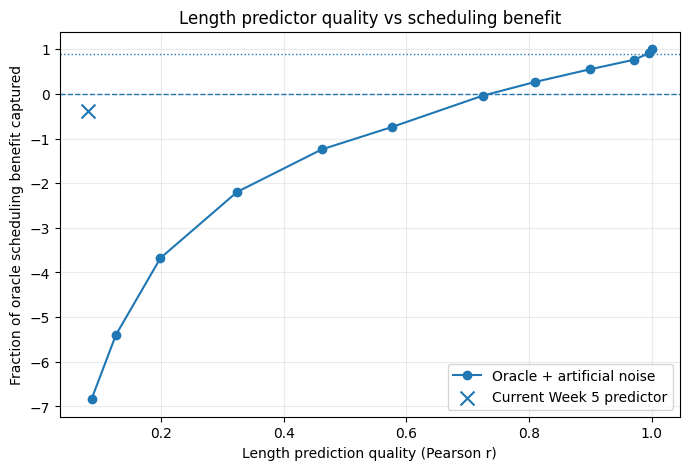


✓ Noise sweep changes prediction quality only.
✓ True logged workload and scheduling algorithm stay fixed.
✓ Current real predictor shown without retraining.


In [45]:
# ------------------------------------------------------------
# Task 3 — Step 12
# Length predictor quality -> scheduler benefit curve
#
# Start from oracle lengths.
# Add increasing Gaussian noise.
# Measure:
#   - achieved prediction correlation
#   - makespan
#   - fraction of oracle benefit captured
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

N_NOISE_TRIALS = 200
NOISE_SEED = 12345

# Noise measured in multiples of each batch's
# true response-length standard deviation.
noise_scales = [
    0.00,
    0.10,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00,
    3.00,
    5.00,
    8.00,
    12.00,
]

rng_noise = np.random.default_rng(
    NOISE_SEED
)

noise_rows = []

for noise_scale in noise_scales:

    trial_rows = []

    for trial in range(N_NOISE_TRIALS):

        all_true = []
        all_estimated = []

        total_makespan = 0.0

        for batch in range(9, 17):

            df = (
                predicted_trace[
                    predicted_trace["batch_step"] == batch
                ]
                .copy()
                .reset_index(drop=True)
            )

            true_costs = (
                df["mean_resp_len"]
                .to_numpy(dtype=float)
            )

            batch_std = true_costs.std(
                ddof=0
            )

            # Oracle + controlled additive noise
            noise = rng_noise.normal(
                loc=0.0,
                scale=noise_scale * batch_std,
                size=len(true_costs),
            )

            estimated_costs = (
                true_costs + noise
            )

            # Response-length estimates cannot be negative.
            estimated_costs = np.clip(
                estimated_costs,
                1.0,
                None,
            )

            result = simulate_assignment(
                true_costs=true_costs,
                estimated_costs=estimated_costs,
                n_workers=N_WORKERS,
            )

            total_makespan += (
                result["makespan"]
            )

            all_true.extend(
                true_costs
            )

            all_estimated.extend(
                estimated_costs
            )

        achieved_r = pearsonr(
            all_estimated,
            all_true
        ).statistic

        oracle_gain = (
            random_total
            - oracle_total
        )

        noisy_gain = (
            random_total
            - total_makespan
        )

        benefit_captured = (
            noisy_gain / oracle_gain
            if oracle_gain > 0
            else np.nan
        )

        trial_rows.append({
            "achieved_r": achieved_r,
            "total_makespan": total_makespan,
            "benefit_captured": benefit_captured,
        })

    trial_df = pd.DataFrame(
        trial_rows
    )

    noise_rows.append({
        "noise_scale": noise_scale,

        "mean_r": (
            trial_df["achieved_r"].mean()
        ),

        "std_r": (
            trial_df["achieved_r"].std(ddof=1)
        ),

        "mean_makespan": (
            trial_df["total_makespan"].mean()
        ),

        "std_makespan": (
            trial_df["total_makespan"].std(ddof=1)
        ),

        "mean_oracle_benefit_captured": (
            trial_df["benefit_captured"].mean()
        ),

        "std_oracle_benefit_captured": (
            trial_df["benefit_captured"].std(ddof=1)
        ),
    })


benefit_curve = pd.DataFrame(
    noise_rows
)

print("=== LENGTH QUALITY -> SCHEDULER BENEFIT ===")

display(
    benefit_curve.round(4)
)


# ------------------------------------------------------------
# Current real predictor point
# ------------------------------------------------------------

current_r = (
    length_pearson.statistic
)

current_benefit = (
    captured_total
)

print("\n=== CURRENT REAL PREDICTOR ===")
print(
    f"Pearson r               : {current_r:.4f}"
)
print(
    f"Oracle benefit captured : {current_benefit:.4f}"
)


# ------------------------------------------------------------
# Approximate quality required for 90% oracle benefit
# using only tested noise conditions.
# ------------------------------------------------------------

qualifying = benefit_curve[
    benefit_curve[
        "mean_oracle_benefit_captured"
    ] >= 0.90
]

if len(qualifying):

    r_for_90 = (
        qualifying["mean_r"].min()
    )

    print(
        "\nLowest tested mean r achieving >=90% "
        f"oracle benefit: {r_for_90:.4f}"
    )

else:
    r_for_90 = np.nan

    print(
        "\nNo tested predictor quality achieved "
        ">=90% oracle benefit."
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plot_df = (
    benefit_curve
    .sort_values("mean_r")
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    plot_df["mean_r"],
    plot_df["mean_oracle_benefit_captured"],
    marker="o",
    label="Oracle + artificial noise",
)

plt.scatter(
    [current_r],
    [current_benefit],
    marker="x",
    s=100,
    label="Current Week 5 predictor",
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    0.90,
    linestyle=":",
    linewidth=1,
)

plt.xlabel(
    "Length prediction quality (Pearson r)"
)

plt.ylabel(
    "Fraction of oracle scheduling benefit captured"
)

plt.title(
    "Length predictor quality vs scheduling benefit"
)

plt.legend()
plt.grid(
    alpha=0.25
)

plt.show()

print(
    "\n✓ Noise sweep changes prediction quality only."
)
print(
    "✓ True logged workload and scheduling algorithm stay fixed."
)
print(
    "✓ Current real predictor shown without retraining."
)

# Step 13: Freeze the final ablation artifacts

=== FINAL LENGTH ABLATION ===


,condition,total_makespan,vs_random_pct,oracle_benefit_captured_pct
0,Oracle,384695.60,3.587,100.000
1,Predicted,404411.80,-1.354,-37.742
2,Random,399009.43,0.000,0.000



=== FINAL DIFFICULTY ABLATION ===


,scheduler,n_skipped,dead_skip_recall,informative_skip_rate,skip_precision,work_removed_fraction,dead_work_removed,informative_work_wrongly_removed
0,Oracle,222,1.0000,0.0000,1.0000,0.2543,195637.0,0.0
1,Predicted,223,0.3874,0.1708,0.3857,0.2417,84930.2,100986.8
2,NoOp,0,0.0000,0.0000,NaN,0.0000,0.0,0.0



=== OBJECTIVE 3 CHECKPOINT ===


,metric,value
0,Current length Pearson r,0.0808
1,Current oracle benefit captured,-0.3774
2,Lowest tested r with >=90% oracle benefit,0.9952
3,Oracle makespan improvement vs random,0.0359
4,Predicted makespan improvement vs random,-0.0135
5,Difficulty dead AUC,0.6562
6,Difficulty informative skip rate,0.1708


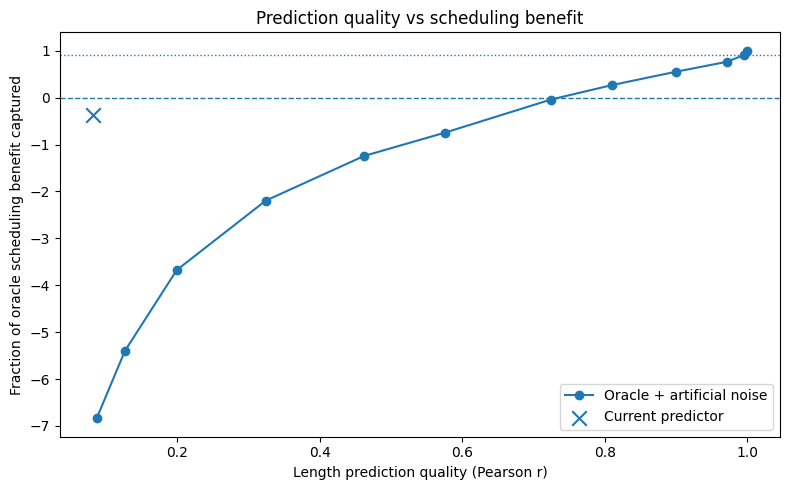


=== FROZEN INTERPRETATION ===
Oracle length scheduling reduces makespan by 3.59% relative to random.
The current length predictor has r=0.0808 and changes makespan by -1.35% relative to random.
It therefore captures -37.7% of oracle benefit (negative means worse than random).
Under the tested additive-noise corruption family, the lowest tested mean correlation achieving >=90% oracle benefit is r=0.9952.
Pearson r is not a sufficient statistic for scheduler utility: real and synthetic predictors with similar r can produce different makespan effects.

Difficulty predictor: AUC=0.6562; frozen hard-skip rule removes 24.17% of work but wrongly skips 17.08% of informative prompts.

Saved to:
C:\Users\waqar\OneDrive\Desktop\Fellowship\week5_task3_results

✓ Objective 3 artifacts frozen.


In [46]:
# ------------------------------------------------------------
# Task 3 — Step 13
# Freeze final Objective 3 results + artifacts
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path(
    r"C:\Users\waqar\OneDrive\Desktop\Fellowship\week5_task3_results"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Final length scheduler comparison
# ============================================================

final_length_table = pd.DataFrame([
    {
        "condition": "Oracle",
        "total_makespan": oracle_total,
        "vs_random_pct": (
            (random_total - oracle_total)
            / random_total * 100
        ),
        "oracle_benefit_captured_pct": 100.0,
    },
    {
        "condition": "Predicted",
        "total_makespan": predicted_total,
        "vs_random_pct": (
            (random_total - predicted_total)
            / random_total * 100
        ),
        "oracle_benefit_captured_pct": (
            captured_total * 100
        ),
    },
    {
        "condition": "Random",
        "total_makespan": random_total,
        "vs_random_pct": 0.0,
        "oracle_benefit_captured_pct": 0.0,
    },
])

print("=== FINAL LENGTH ABLATION ===")
display(final_length_table.round(3))


# ============================================================
# 2. Final difficulty comparison
# ============================================================

final_difficulty_table = (
    difficulty_ablation[
        [
            "scheduler",
            "n_skipped",
            "dead_skip_recall",
            "informative_skip_rate",
            "skip_precision",
        ]
    ]
    .copy()
)

final_difficulty_table = final_difficulty_table.merge(
    difficulty_workload[
        [
            "scheduler",
            "work_removed_fraction",
            "dead_work_removed",
            "informative_work_wrongly_removed",
        ]
    ],
    on="scheduler",
    how="left",
)

print("\n=== FINAL DIFFICULTY ABLATION ===")
display(final_difficulty_table.round(4))


# ============================================================
# 3. Final predictor-quality checkpoint
# ============================================================

r90 = (
    benefit_curve.loc[
        benefit_curve[
            "mean_oracle_benefit_captured"
        ] >= 0.90,
        "mean_r",
    ].min()
)

checkpoint = pd.DataFrame([
    {
        "metric": "Current length Pearson r",
        "value": float(length_pearson.statistic),
    },
    {
        "metric": "Current oracle benefit captured",
        "value": float(captured_total),
    },
    {
        "metric": "Lowest tested r with >=90% oracle benefit",
        "value": float(r90),
    },
    {
        "metric": "Oracle makespan improvement vs random",
        "value": float(
            (random_total - oracle_total)
            / random_total
        ),
    },
    {
        "metric": "Predicted makespan improvement vs random",
        "value": float(
            (random_total - predicted_total)
            / random_total
        ),
    },
    {
        "metric": "Difficulty dead AUC",
        "value": float(dead_auc),
    },
    {
        "metric": "Difficulty informative skip rate",
        "value": float(informative_skip_rate),
    },
])

print("\n=== OBJECTIVE 3 CHECKPOINT ===")
display(checkpoint.round(4))


# ============================================================
# 4. Save tables
# ============================================================

final_length_table.to_csv(
    RESULTS_DIR / "length_oracle_predicted_random.csv",
    index=False,
)

final_difficulty_table.to_csv(
    RESULTS_DIR / "difficulty_oracle_predicted_noop.csv",
    index=False,
)

benefit_curve.to_csv(
    RESULTS_DIR / "length_benefit_vs_error.csv",
    index=False,
)

quality_by_batch.to_csv(
    RESULTS_DIR / "predictor_quality_by_batch.csv",
    index=False,
)

checkpoint.to_csv(
    RESULTS_DIR / "objective3_checkpoint.csv",
    index=False,
)


# ============================================================
# 5. Re-create paper-ready benefit curve
# ============================================================

plot_df = benefit_curve.sort_values(
    "mean_r"
)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["mean_r"],
    plot_df["mean_oracle_benefit_captured"],
    marker="o",
    label="Oracle + artificial noise",
)

plt.scatter(
    [length_pearson.statistic],
    [captured_total],
    marker="x",
    s=110,
    label="Current predictor",
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    0.90,
    linestyle=":",
    linewidth=1,
)

plt.xlabel("Length prediction quality (Pearson r)")
plt.ylabel("Fraction of oracle scheduling benefit captured")
plt.title("Prediction quality vs scheduling benefit")
plt.legend()
plt.tight_layout()

FIG_PATH = (
    RESULTS_DIR
    / "length_prediction_quality_vs_scheduler_benefit.png"
)

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 6. Record interpretation without overclaiming
# ============================================================

print("\n=== FROZEN INTERPRETATION ===")

print(
    f"Oracle length scheduling reduces makespan by "
    f"{(random_total-oracle_total)/random_total*100:.2f}% "
    "relative to random."
)

print(
    f"The current length predictor has r="
    f"{length_pearson.statistic:.4f} and changes makespan by "
    f"{(random_total-predicted_total)/random_total*100:.2f}% "
    "relative to random."
)

print(
    f"It therefore captures {captured_total*100:.1f}% "
    "of oracle benefit (negative means worse than random)."
)

print(
    f"Under the tested additive-noise corruption family, "
    f"the lowest tested mean correlation achieving >=90% "
    f"oracle benefit is r={r90:.4f}."
)

print(
    "Pearson r is not a sufficient statistic for scheduler utility: "
    "real and synthetic predictors with similar r can produce "
    "different makespan effects."
)

print(
    f"\nDifficulty predictor: AUC={dead_auc:.4f}; "
    f"frozen hard-skip rule removes "
    f"{difficulty_workload.loc[difficulty_workload.scheduler=='Predicted', 'work_removed_fraction'].iloc[0]*100:.2f}% "
    f"of work but wrongly skips "
    f"{informative_skip_rate*100:.2f}% of informative prompts."
)

print("\nSaved to:")
print(RESULTS_DIR)

print("\n✓ Objective 3 artifacts frozen.")

# Task 4 — Step 1: Benchmark 128-prompt inference

In [47]:
# ------------------------------------------------------------
# Task 4 — Step 1
# Benchmark the Week 5 history-predictor inference path
# on a scheduler-sized batch of 128 prompts.
#
# Measures:
#   history lookup
#   length prediction
#   pass-rate prediction
#   dead-probability prediction
#   payload construction
#
# Excludes disk/network I/O and scheduler logic.
# ------------------------------------------------------------

import time
import numpy as np
import pandas as pd

# Deterministic cold-start defaults inherited from prior work.
COLD_START_LENGTH = 556.992
COLD_START_PASS_RATE = 0.2083

# Use one real 128-prompt batch only as benchmark inputs.
bench_df = (
    predicted_trace[
        predicted_trace["batch_step"] == 16
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(bench_df) == 128

# Reconstruct exactly the history that each benchmark item
# is allowed to see.
benchmark_history = {
    row["example_key"]: {
        "prev_pass_rate": float(row["prev_pass_rate"]),
        "prev_mean_resp_len": float(row["prev_mean_resp_len"]),
    }
    for _, row in bench_df.iterrows()
}

benchmark_ids = bench_df["example_key"].tolist()


def predict_contract_batch(prompt_ids, history):
    """
    Scheduler-facing Week 5 prediction kernel.

    Stable prompt IDs are supplied by the caller.
    This function does NOT inspect rollout outcomes from the
    current batch.
    """

    n = len(prompt_ids)

    cold_start = np.zeros(n, dtype=bool)
    pred_len = np.empty(n, dtype=float)
    pred_pass = np.empty(n, dtype=float)

    for i, prompt_id in enumerate(prompt_ids):
        state = history.get(prompt_id)

        if state is None:
            cold_start[i] = True
            pred_len[i] = COLD_START_LENGTH
            pred_pass[i] = COLD_START_PASS_RATE
        else:
            pred_len[i] = state["prev_mean_resp_len"]
            pred_pass[i] = state["prev_pass_rate"]

    # Frozen Task 1 dead-probability model.
    X_dead = pd.DataFrame({
        "prev_pass_rate": pred_pass
    })

    pred_dead = (
        final_dead_model
        .predict_proba(X_dead)[:, 1]
    )

    payload = [
        {
            "prompt_id": prompt_ids[i],
            "predicted_response_length": float(pred_len[i]),
            "predicted_pass_rate": float(pred_pass[i]),
            "predicted_dead_prob": float(pred_dead[i]),
            "cold_start": bool(cold_start[i]),
        }
        for i in range(n)
    ]

    return payload


# ------------------------------------------------------------
# Correctness smoke check
# ------------------------------------------------------------

example_output = predict_contract_batch(
    benchmark_ids,
    benchmark_history,
)

assert len(example_output) == 128
assert all(
    set(row) == {
        "prompt_id",
        "predicted_response_length",
        "predicted_pass_rate",
        "predicted_dead_prob",
        "cold_start",
    }
    for row in example_output
)

print("=== SAMPLE OUTPUT ===")
print(example_output[0])


# ------------------------------------------------------------
# Timing
# ------------------------------------------------------------

N_WARMUP = 50
N_RUNS = 1000

for _ in range(N_WARMUP):
    predict_contract_batch(
        benchmark_ids,
        benchmark_history,
    )

times_ms = []

for _ in range(N_RUNS):
    t0 = time.perf_counter()

    predict_contract_batch(
        benchmark_ids,
        benchmark_history,
    )

    times_ms.append(
        (time.perf_counter() - t0) * 1000
    )

times_ms = np.asarray(times_ms)

print("\n=== 128-PROMPT PREDICTION LATENCY ===")
print(f"Runs       : {N_RUNS}")
print(f"Mean       : {times_ms.mean():.4f} ms")
print(f"Median/P50 : {np.median(times_ms):.4f} ms")
print(f"P95        : {np.percentile(times_ms, 95):.4f} ms")
print(f"P99        : {np.percentile(times_ms, 99):.4f} ms")
print(f"Min        : {times_ms.min():.4f} ms")
print(f"Max        : {times_ms.max():.4f} ms")

# If predictor must be <5% of a rollout step,
# this tells us how long the rollout step must be at minimum.
p95_ms = np.percentile(times_ms, 95)

print(
    "\nFor P95 predictor latency to be <5% of a rollout step,"
)
print(
    f"rollout step wall time must exceed "
    f"{p95_ms / 0.05:.2f} ms "
    f"({p95_ms / 0.05 / 1000:.4f} s)."
)

print(
    "\nNOTE: percentage-of-rollout-step cannot be claimed "
    "until we have a measured rollout-step wall-clock time."
)

=== SAMPLE OUTPUT ===
{'prompt_id': '01816da10c39e831533a48a90748dbc56ae2f933c0dde7c0c039aa9b6b856897', 'predicted_response_length': 367.8, 'predicted_pass_rate': 0.2, 'predicted_dead_prob': 0.3705166074735621, 'cold_start': False}

=== 128-PROMPT PREDICTION LATENCY ===
Runs       : 1000
Mean       : 0.6991 ms
Median/P50 : 0.5385 ms
P95        : 1.3399 ms
P99        : 2.8079 ms
Min        : 0.4065 ms
Max        : 10.0272 ms

For P95 predictor latency to be <5% of a rollout step,
rollout step wall time must exceed 26.80 ms (0.0268 s).

NOTE: percentage-of-rollout-step cannot be claimed until we have a measured rollout-step wall-clock time.


# DUET Predictor Contract

**Status:** Week 5 frozen research contract  
**Consumer:** Sam's scheduler  
**Scope:** History-based response-length and difficulty prediction

---

## 1. Scheduler-facing interface

The predictor returns one record per prompt:

```python
predict(prompt_id, prompt_text=None) -> {
    "prompt_id": str,
    "predicted_response_length": float,
    "predicted_pass_rate": float,
    "predicted_dead_prob": float,
    "cold_start": bool,
}
```

Batch form:

```python
predict_batch(prompt_ids, prompt_texts=None) -> list[Prediction]
```

These five fields are the frozen Week 5 contract.

`prompt_text` is optional in the current history-based predictor. It is reserved so a future cold-start content prior can be added without changing the scheduler interface.

---

## 2. Stable prompt identity

`prompt_id` must remain stable across repeated appearances of the same underlying training example.

Preferred source:

**A persistent dataset/source-example ID supplied by the trainer or datastore.**

Do not use:

- rollout UUIDs from exported traces, because they are regenerated across occurrences
- reward or score
- response text
- response length
- any outcome from the current occurrence
- `gts` as part of production-time prompt identity

For offline Week 5 analysis, stable identities had to be reconstructed from the exports because the rollout UUIDs were occurrence-specific.

Production should use a persistent trainer/datastore identifier instead.

---

## 3. Prediction semantics

### `predicted_response_length`

Current history predictor:

> Previous observed mean response length for the most recent completed occurrence of the prompt.

Cold-start prior:

> **556.992 tokens**

Independent 16-batch trace performance:

- Pearson correlation: **r = 0.0808**
- Predicted 2-worker scheduling vs random: **1.35% worse**
- Oracle 2-worker scheduling vs random: **3.59% better**
- Fraction of oracle benefit captured by current predictor: **-37.7%**

The oracle result proves that scheduling headroom exists.

The current length predictor is not accurate enough to exploit that headroom reliably.

### Current guidance

`predicted_response_length` is suitable for:

- logging
- offline analysis
- experimental scheduling ablations

It should **not enable production length-based packing by default yet**.

---

### `predicted_pass_rate`

Current history predictor:

> Previous observed pass rate from the most recent completed occurrence.

This has useful historical information, but it is **not itself a skip decision**.

---

### `predicted_dead_prob`

Current model:

```text
LogisticRegression(previous pass rate -> probability next occurrence is dead)
```

A dead prompt is an occurrence whose rollout group is either:

```text
all-pass
or
all-fail
```

Independent 16-batch trace performance:

- ROC AUC: **0.6562**
- Average precision: **0.3108**
- Brier score: **0.1765**

The frozen Week 5 experimental skip rule:

```text
skip if previous pass rate == 0.0
```

produced:

- dead-skip precision: **0.3857**
- dead-skip recall: **0.3874**
- F1: **0.3865**
- skipped prompts: **223 / 1024**
- informative prompt skip rate: **17.08%**

Therefore `predicted_dead_prob` has useful ranking signal, but it is **not currently safe enough to act as a standalone hard-skip decision**.

---

## 4. Cold start

`cold_start=True` means:

> No valid earlier occurrence exists for this prompt.

It does **not** mean:

- easy
- hard
- dead
- low-value
- uninformative

# DO NOT SKIP COLD-START PROMPTS

Required scheduler behavior:

```python
if prediction["cold_start"]:
    decision = KEEP
```

Numeric priors may still be returned so the API remains deterministic, but those priors must not be interpreted as evidence for a hard skip.

Cold-start defaults used in Week 5:

```text
predicted_response_length = 556.992
predicted_pass_rate        = 0.2083
```

---

## 5. No-leakage execution order

Required ordering:

```text
1. Receive full prompt batch
2. Generate predictions using history from earlier batches only
3. Scheduler makes assignment / KEEP / SKIP decisions
4. Rollouts execute
5. Rewards and response lengths become available
6. Aggregate completed outcomes per stable prompt ID
7. Update predictor history
8. Begin next batch
```

Core invariant:

```text
predict -> observe -> update
```

Never:

```text
observe current outcome -> predict current prompt
```

If the same stable prompt occurs multiple times inside the same batch, every copy must receive the same **pre-batch history**.

Same-batch outcomes may update history only after prediction for the entire batch is complete.

---

## 6. Safe scheduler fallback

The frozen Week 5 integration policy is:

```python
prediction = predictor.predict(...)

if prediction["cold_start"]:
    return KEEP

if prediction is missing or invalid:
    return KEEP

# Current predictor outputs may be logged, ranked,
# or used in explicitly enabled experiments.
```

Safe default:

```text
cold start                 -> KEEP
missing prediction         -> KEEP
invalid prediction         -> KEEP
uncertain hard-skip policy -> KEEP
```

The scheduler should fail open to **KEEP**, not SKIP.

---

## 7. Prediction latency

Benchmark batch size:

> **128 prompts**

Measured path includes:

```text
stable prompt-ID lookup
history lookup
previous-length prediction
previous-pass-rate prediction
dead-probability inference
scheduler payload construction
```

Benchmark procedure:

- 50 warmup runs
- 1,000 timed runs
- local Week 5 notebook environment
- disk/network I/O excluded
- scheduler execution excluded

| Metric | 128-prompt latency |
|---|---:|
| Mean | **0.6991 ms** |
| P50 | **0.5385 ms** |
| P95 | **1.3399 ms** |
| P99 | **2.8079 ms** |

At P95, predictor latency is below 5% of rollout-step wall time whenever the rollout step takes longer than:

> **26.80 ms**

We cannot yet state unconditionally that predictor overhead is `<5% of rollout time`, because a real rollout-step wall-clock measurement has not yet been recorded.

---

## 8. Field trust summary

| Field | Current status | Scheduler guidance |
|---|---|---|
| `prompt_id` | Trustworthy when supplied as a persistent stable ID | Required for history lookup |
| `predicted_response_length` | Weak on independent trace | Logging / ablation only |
| `predicted_pass_rate` | Useful historical statistic | Signal only, not skip authority |
| `predicted_dead_prob` | Moderate ranking signal | Experimental |
| `cold_start` | Trustworthy safety flag | **DO NOT SKIP** |

---

## 9. Oracle vs predicted scheduling result

### Length scheduling

Using 2 virtual workers on the same logged epoch-2 workload:

| Scheduler | Total makespan | vs Random |
|---|---:|---:|
| Oracle | **384,695.6** | **3.59% better** |
| Predicted | **404,411.8** | **1.35% worse** |
| Random | **399,009.4** | Baseline |

Current length predictor:

```text
Pearson r = 0.0808
```

Current fraction of oracle scheduling benefit captured:

```text
-37.7%
```

The negative value means the predicted assignment was worse than random.

The oracle nevertheless demonstrates that useful scheduling headroom exists.

---

## 10. Predictor quality vs scheduler benefit

Oracle response lengths were progressively corrupted with artificial additive noise while holding the logged workload and scheduler fixed.

Results showed that scheduling benefit degrades rapidly as prediction quality falls.

Under this specific additive-noise experiment:

> Lowest tested mean correlation achieving at least 90% of oracle scheduling benefit: **r = 0.9952**

This should **not** be interpreted as a universal requirement that DUET needs `r >= 0.9952`.

The result is conditional on:

- this logged workload
- 2 virtual workers
- this greedy assignment algorithm
- this additive-noise corruption family

A further important observation is that **Pearson correlation alone is not a sufficient statistic for scheduler utility**.

Predictors with similar correlation can produce substantially different makespan effects depending on their error structure.

---

## 11. Difficulty scheduling result

On 1,024 epoch-2 prompt occurrences:

```text
Dead prompts        = 222
Informative prompts = 802
```

### Oracle

- correctly skips dead prompts: **222 / 222**
- dead recall: **100%**
- informative prompts wrongly skipped: **0**
- generation work removed: **25.43%**
- informative work removed: **0**

### Current predicted policy

- prompts skipped: **223**
- dead prompts correctly skipped: **86**
- dead recall: **38.74%**
- informative prompts wrongly skipped: **137**
- informative prompt loss: **17.08%**
- total generation work removed: **24.17%**

Work removed by predicted policy:

```text
dead work correctly removed        = 84,930.2
informative work wrongly removed   = 100,986.8
```

Although the predicted policy removes nearly as much total work as the oracle, more than half of that removed work is informative.

Therefore the current difficulty predictor should **not be deployed as a hard-skip policy**.

---

## 12. Integration requirement for Sam

Sam's scheduler should be able to integrate against this contract without depending on notebook internals.

Minimum interface behavior:

```text
stable prompt ID
        ↓
predictor lookup
        ↓
Prediction {
    predicted_response_length,
    predicted_pass_rate,
    predicted_dead_prob,
    cold_start
}
        ↓
cold_start checked first
        ↓
safe KEEP fallback
        ↓
scheduler decision
        ↓
rollouts execute
        ↓
completed outcomes returned to predictor
        ↓
history update
```

Current outcomes must remain hidden from the predictor until the scheduler decision for that batch is complete.

Any future change to field names or semantics should be coordinated before changing the scheduler implementation.

---

## Week 5 conclusion

History clearly contains predictive signal, particularly for difficulty, but transfer to the independent training trace is substantially weaker than the controlled Week 5 POC.

For response length, the oracle experiment demonstrates real scheduling upside, but the current predictor is below the accuracy required to realize it.

For difficulty, ranking signal survives on the independent trace, but the current hard-skip operating point sacrifices too many informative prompts.

The recommended integration posture is therefore:

> **Expose the predictor interface now, preserve safe KEEP behavior, collect history, log predictions, and keep scheduler actions experimental until predictor quality improves.**

**Week 5 predictor contract: frozen for integration.**